In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("3. Dataset - DA'26.csv")

### Exploratory Data Analysis

(39913, 96)


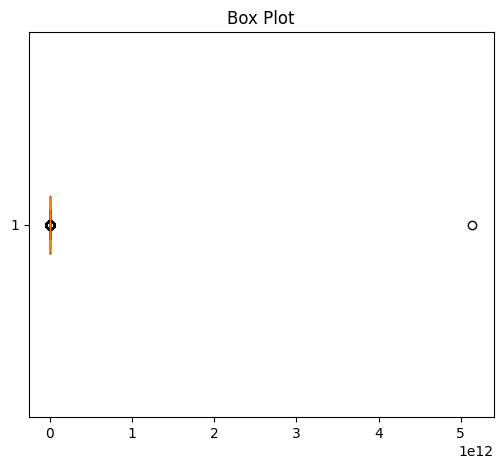

In [4]:
import matplotlib.pyplot as plt
print (df.shape)
plt.figure(figsize=(6,5))
plt.boxplot(df['pl_rade'], vert = False)
plt.title("Box Plot")
plt.show()

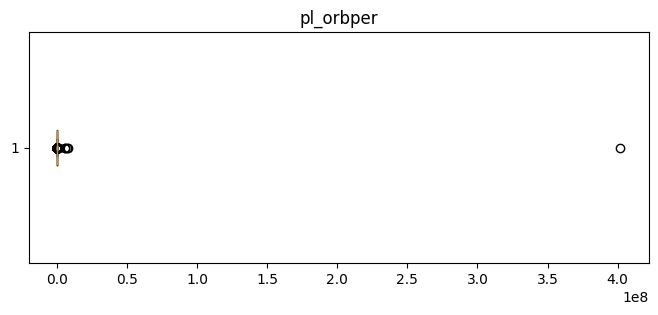

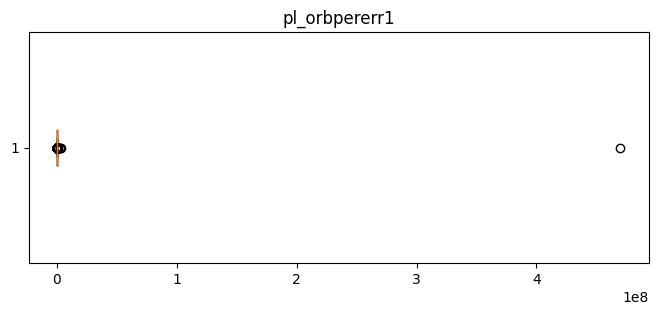

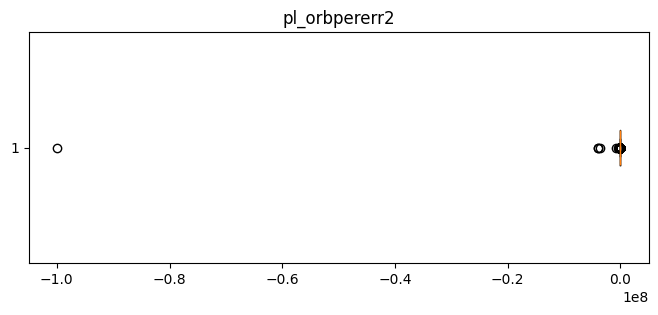

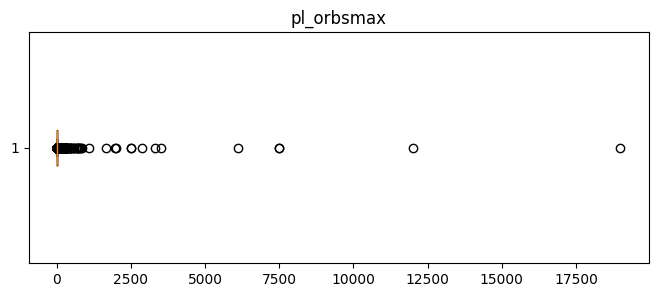

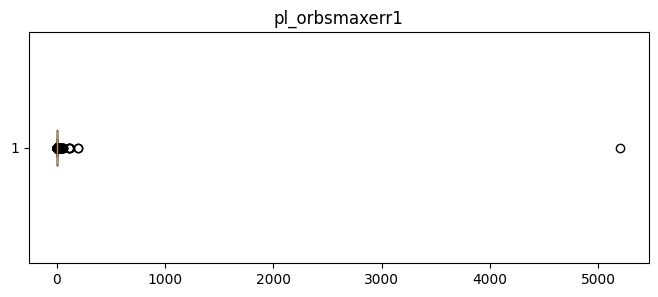

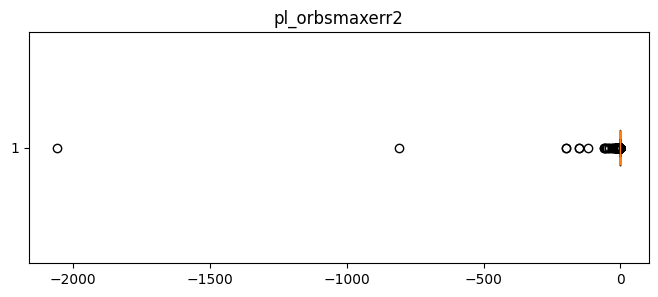

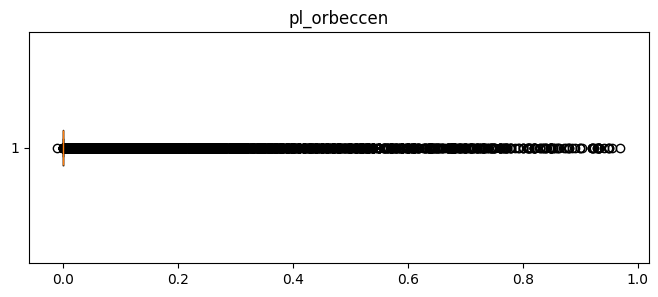

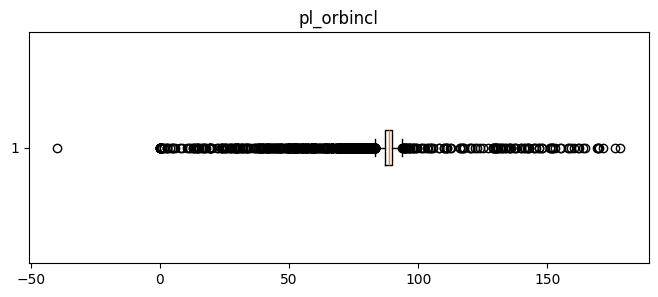

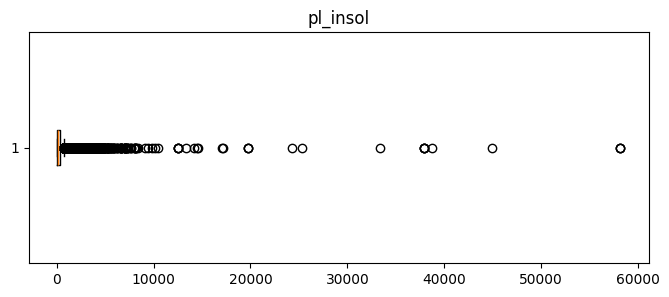

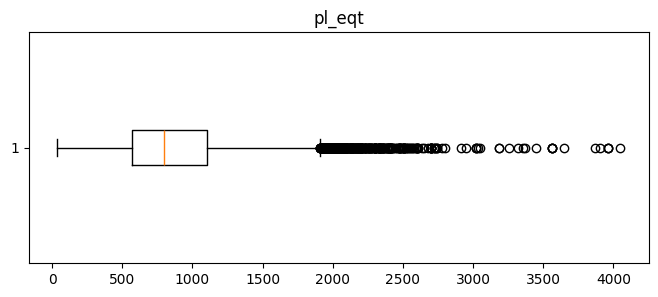

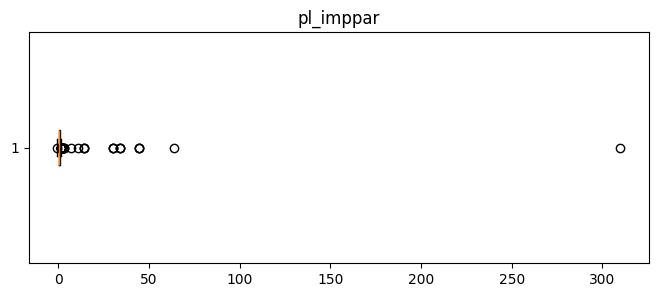

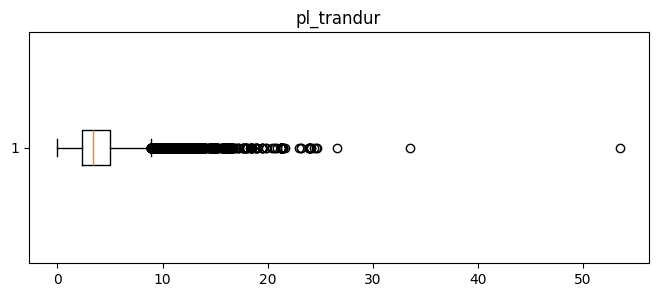

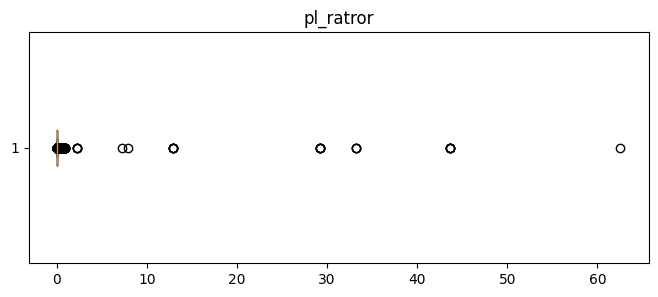

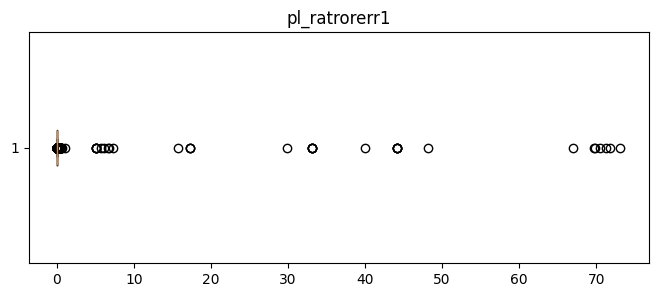

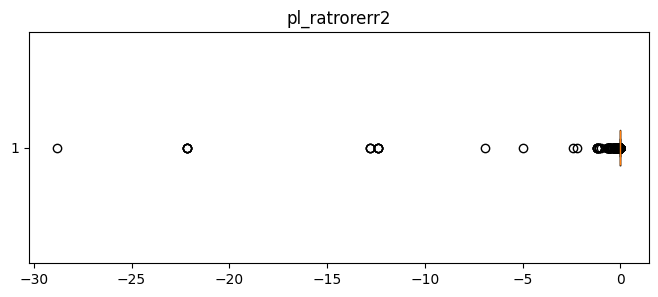

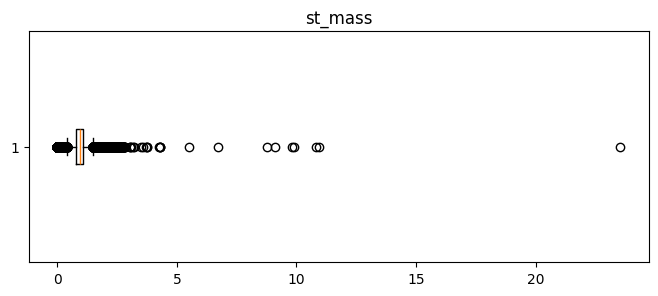

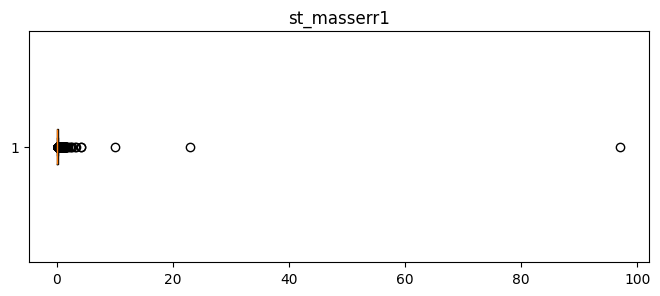

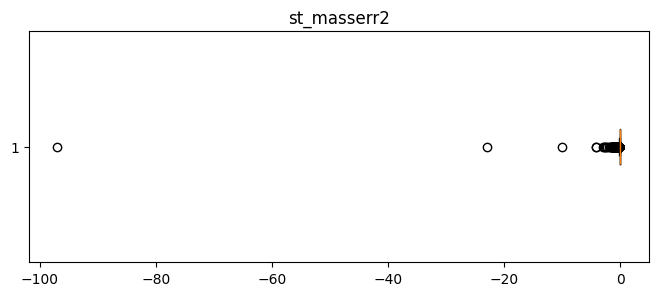

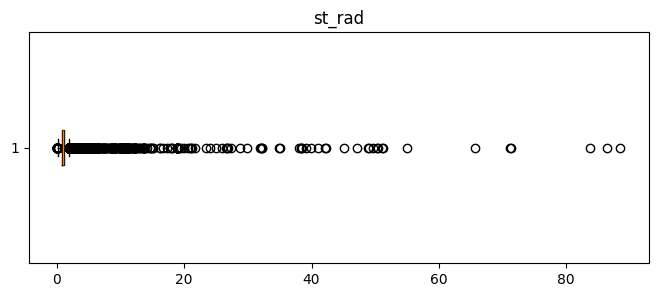

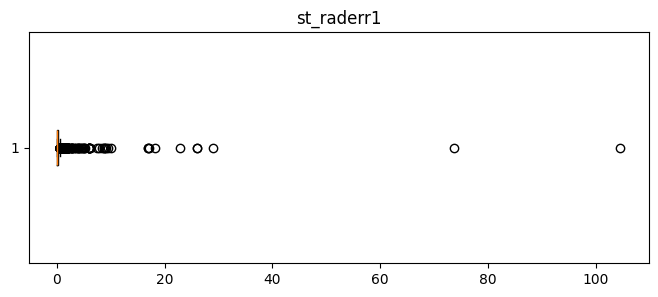

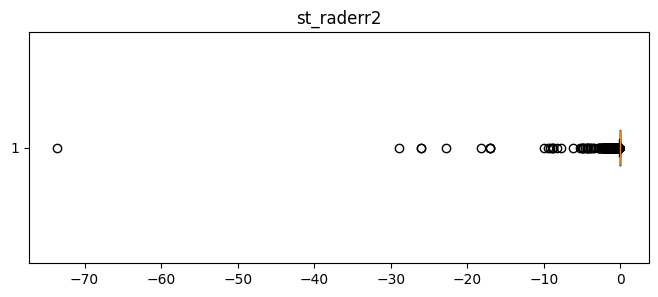

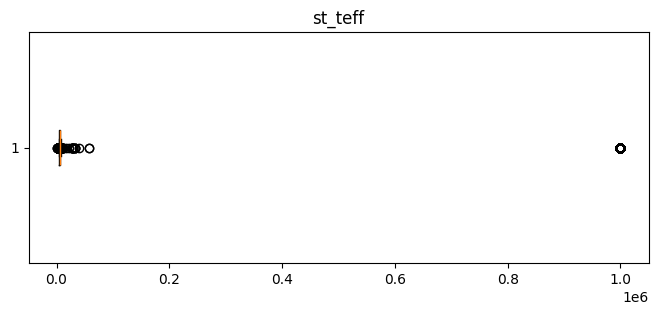

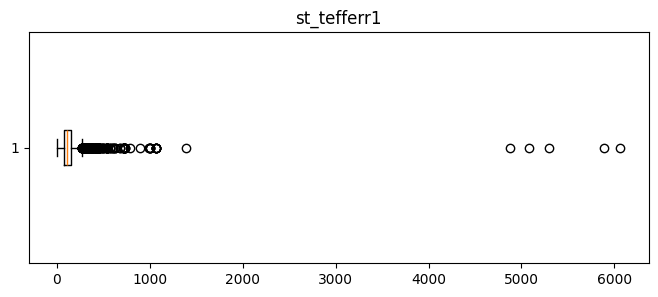

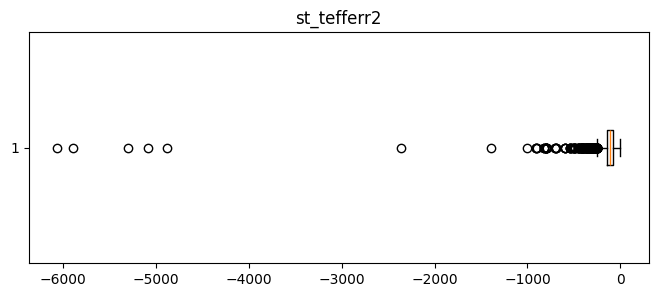

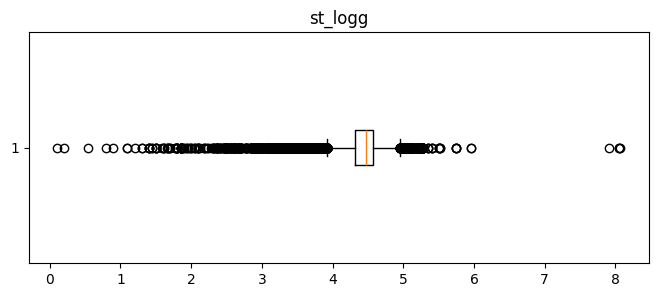

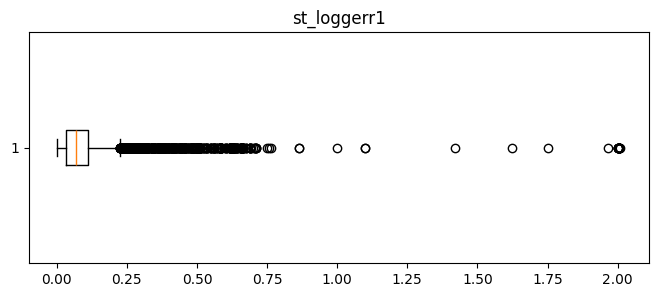

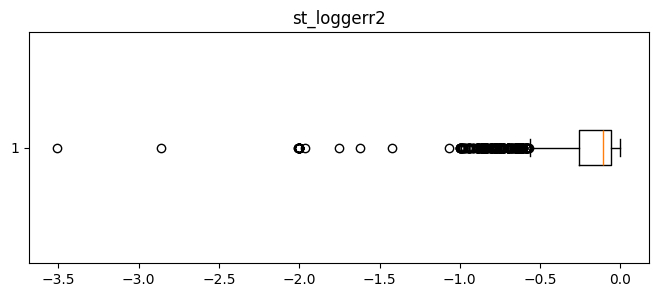

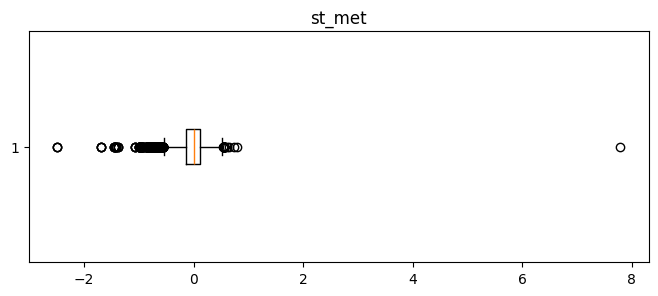

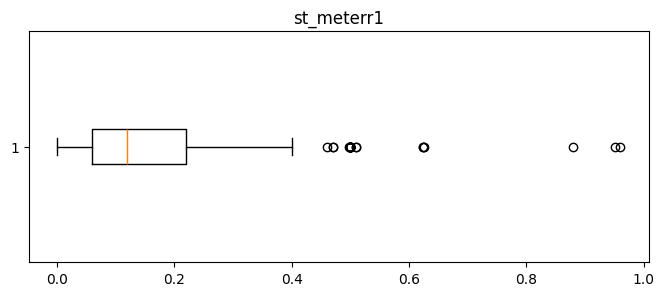

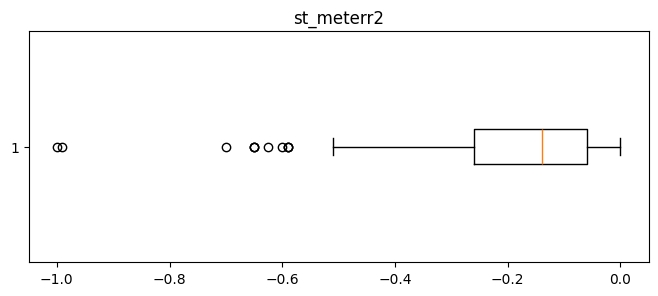

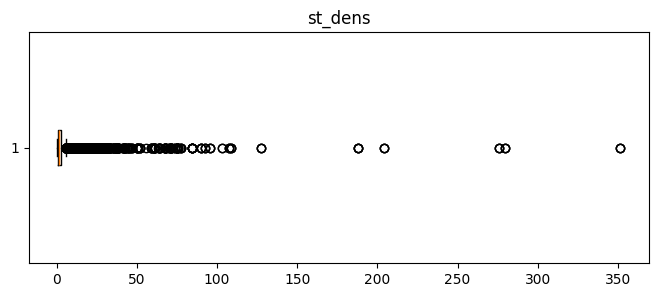

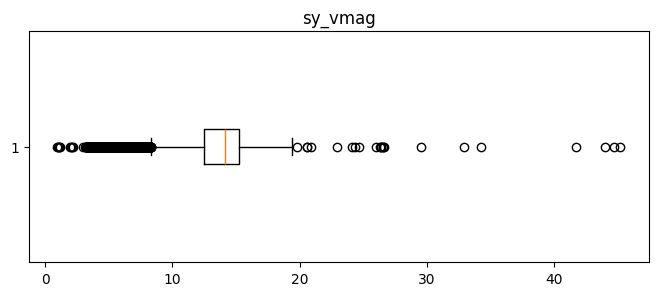

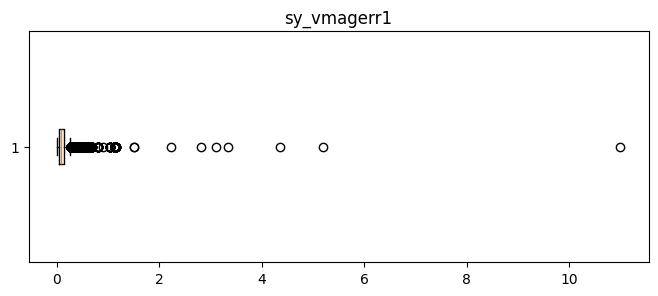

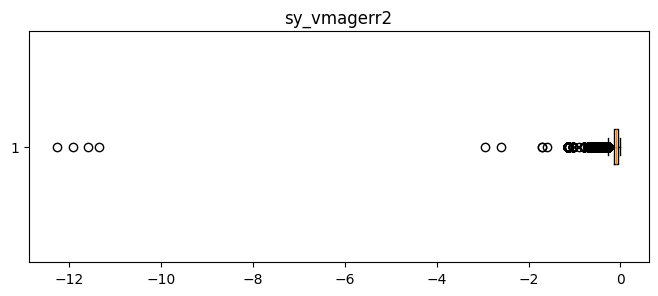

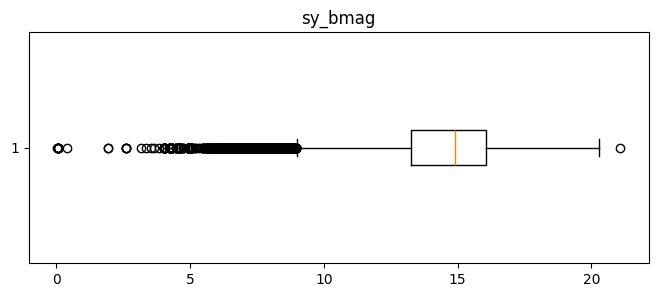

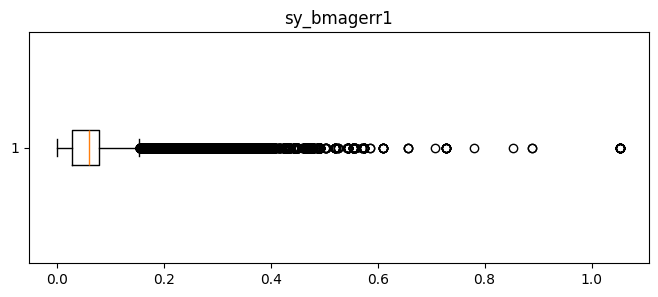

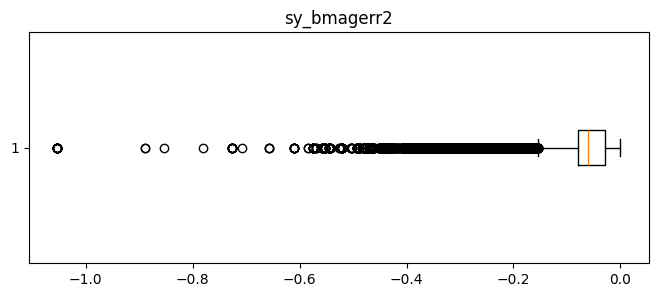

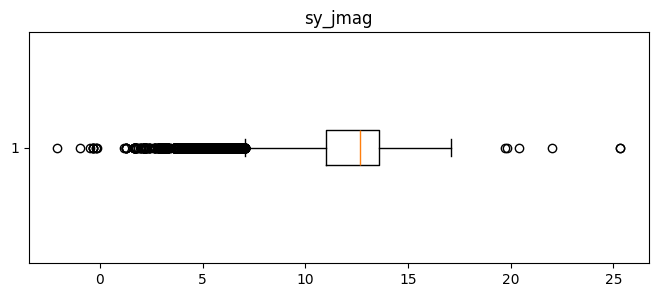

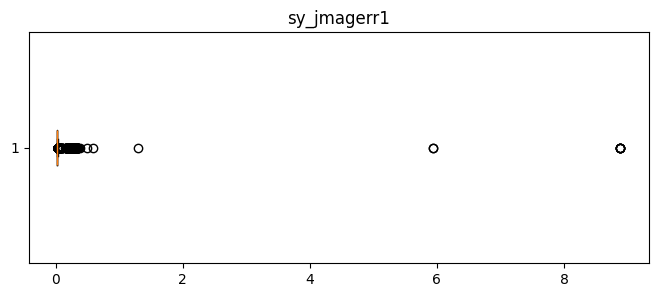

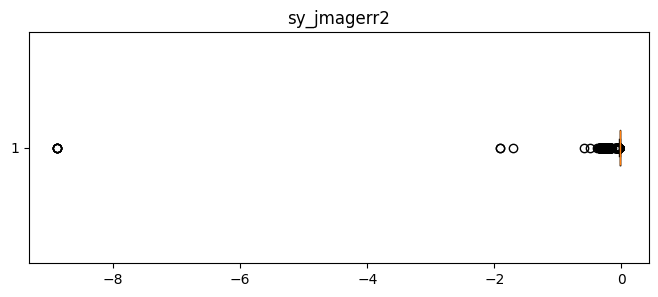

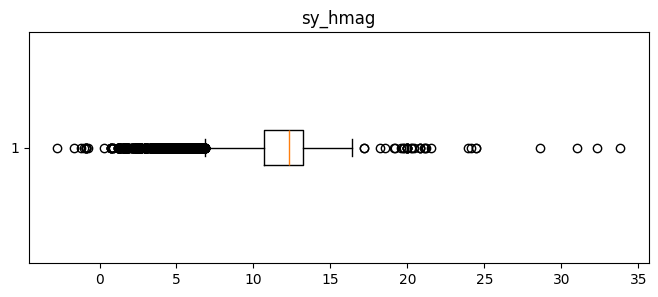

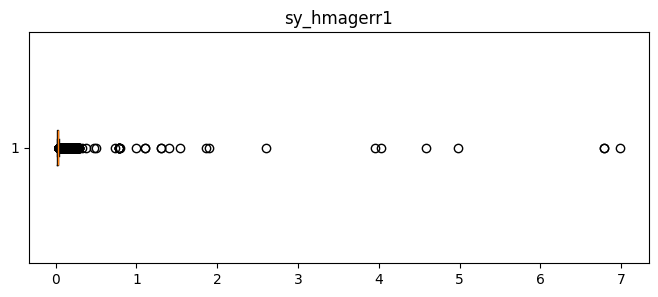

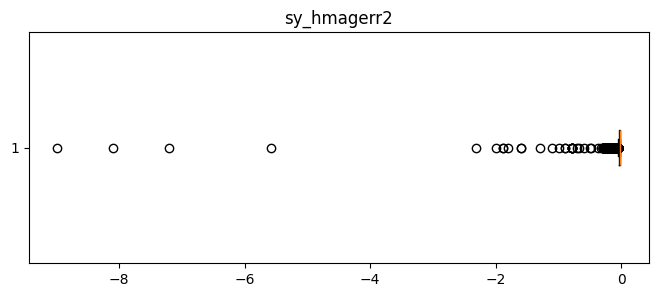

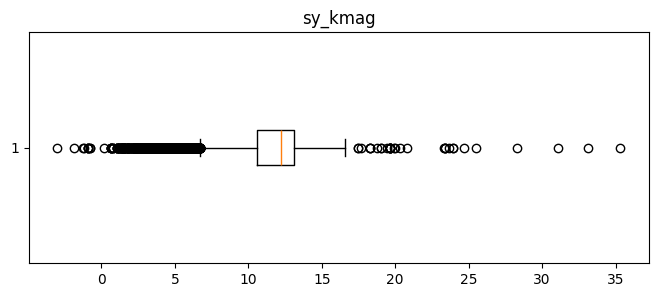

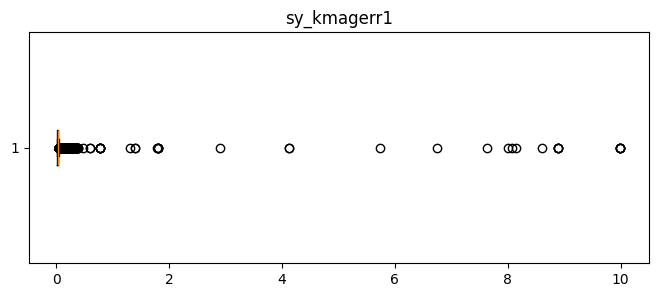

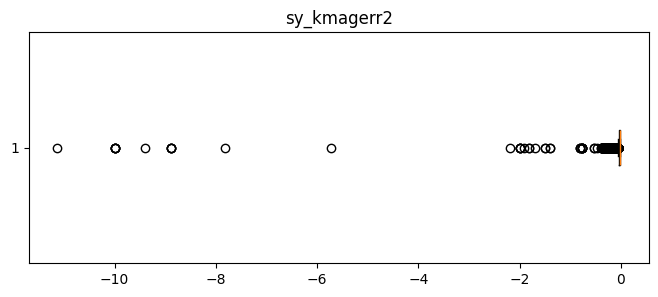

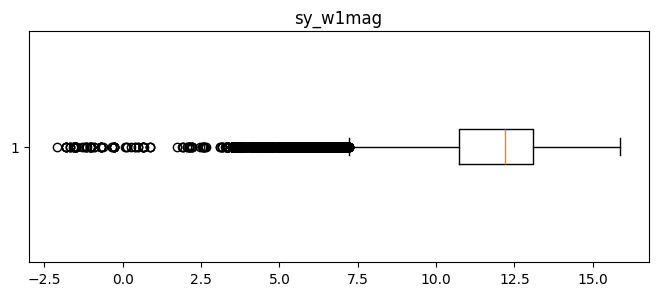

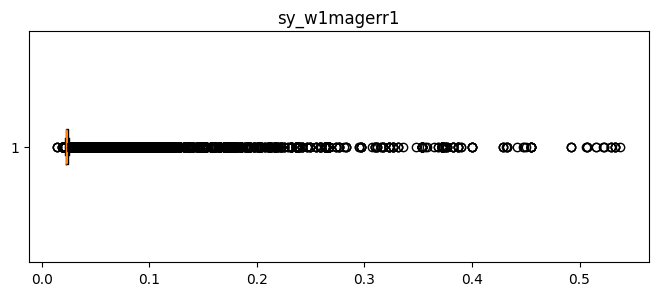

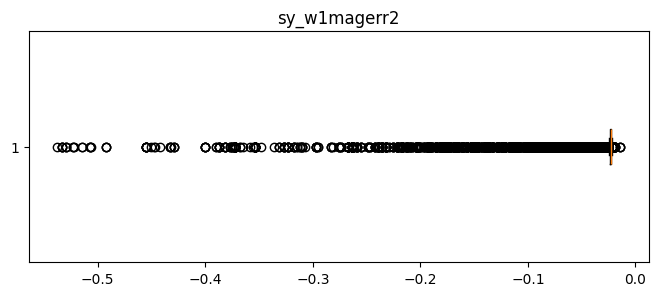

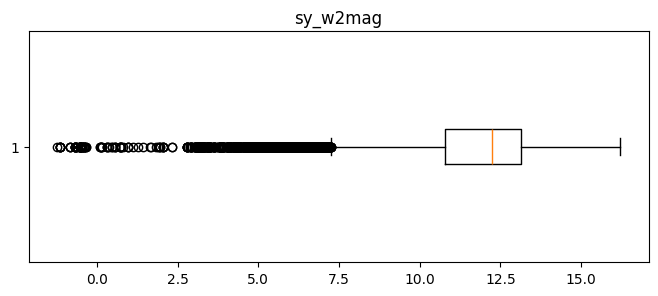

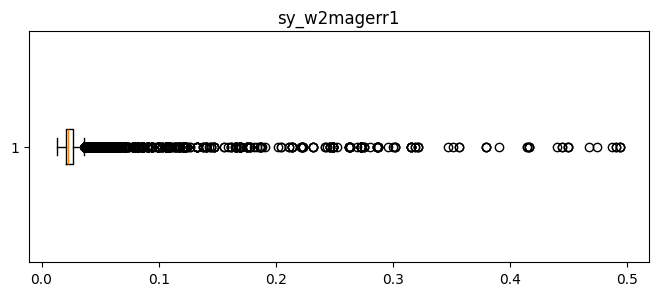

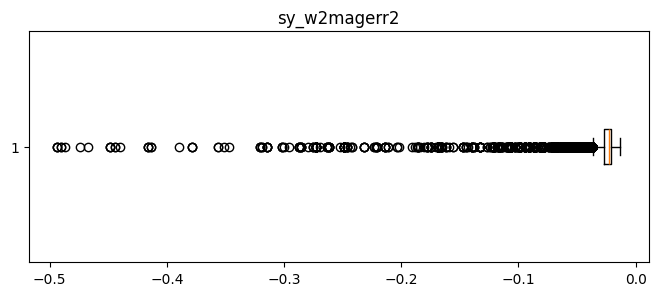

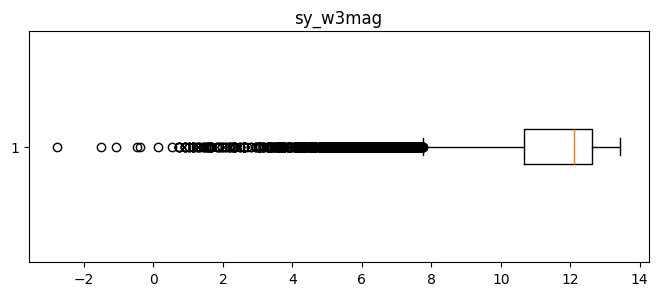

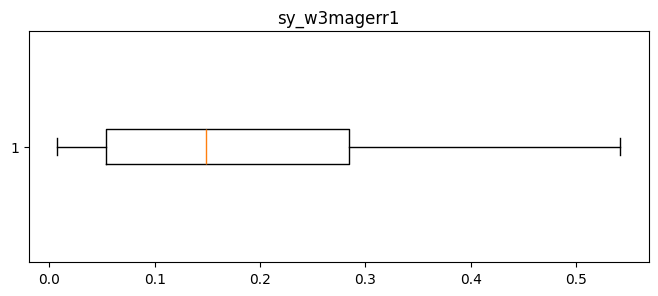

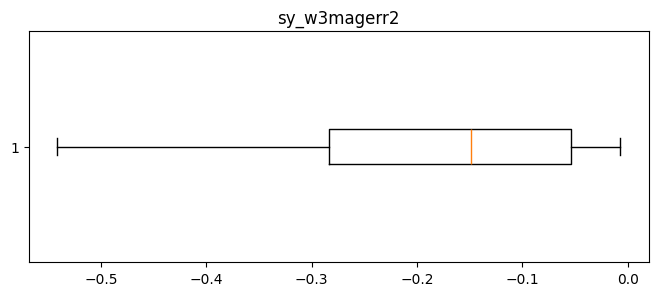

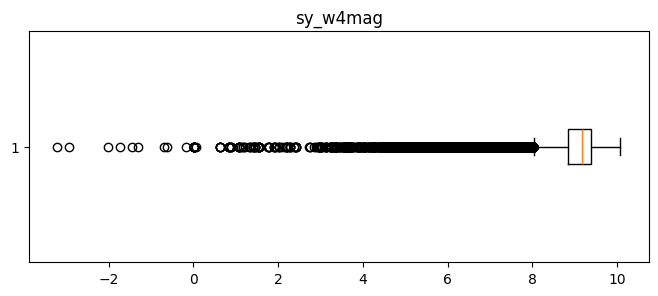

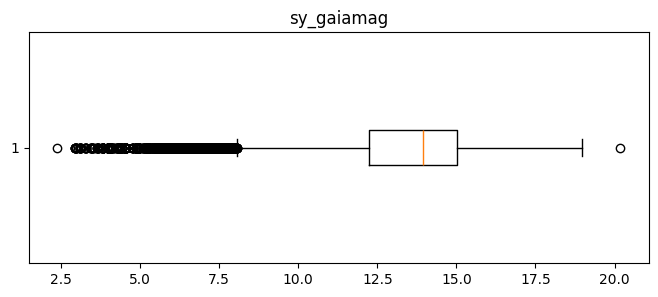

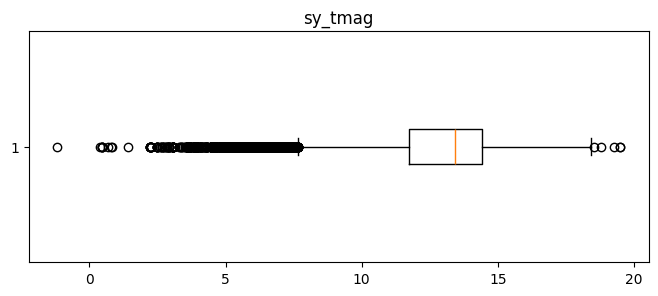

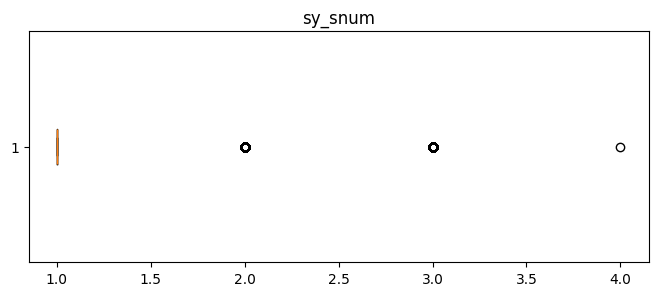

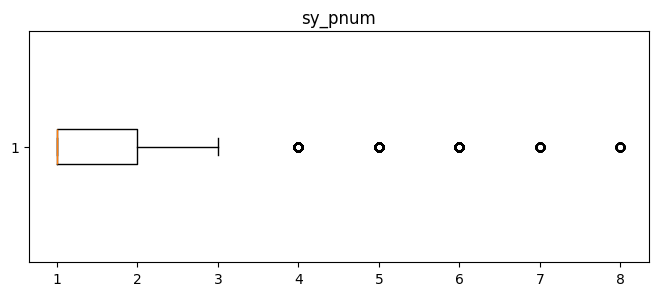

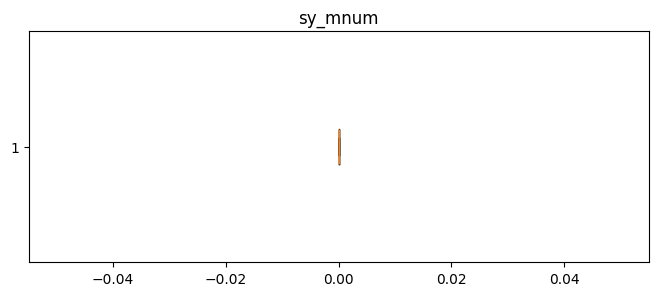

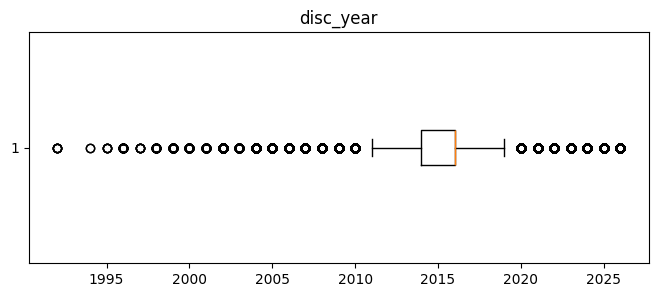

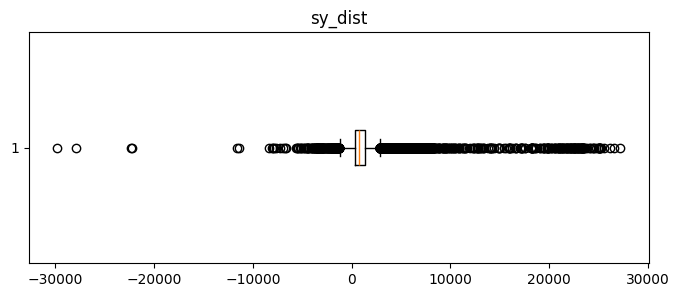

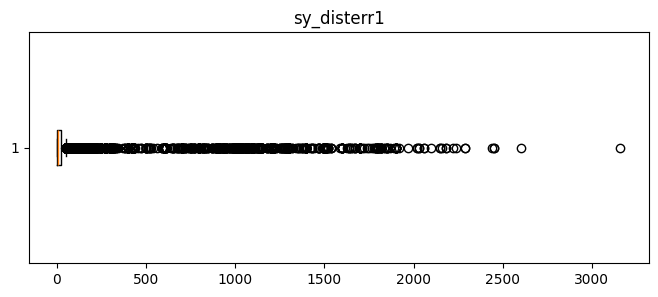

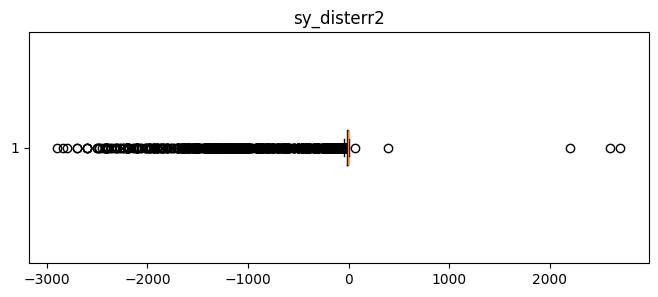

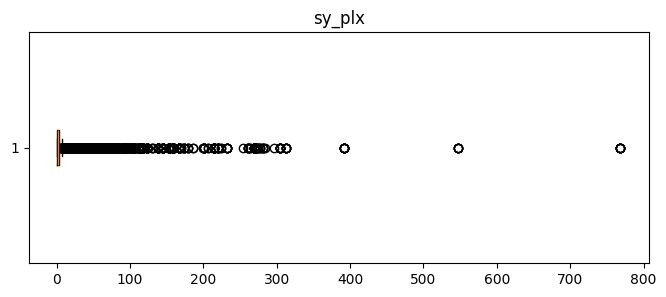

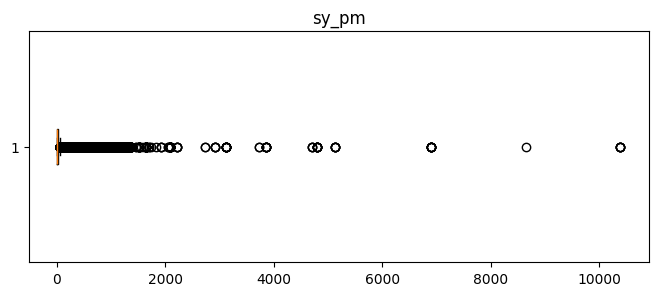

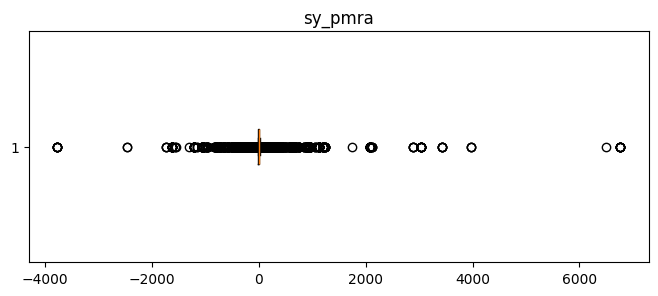

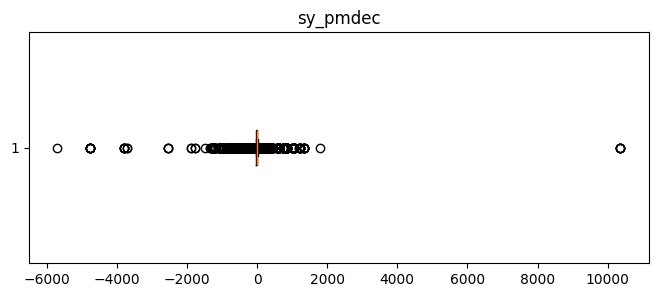

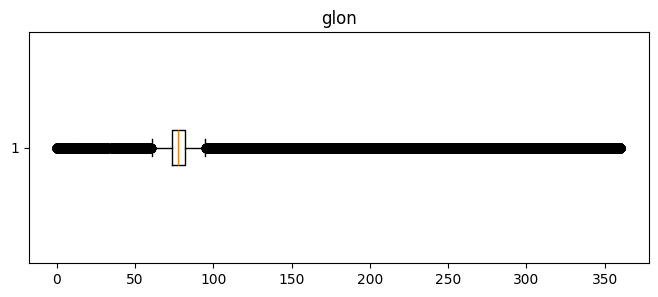

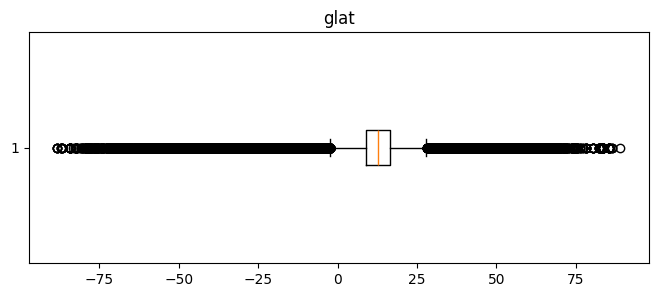

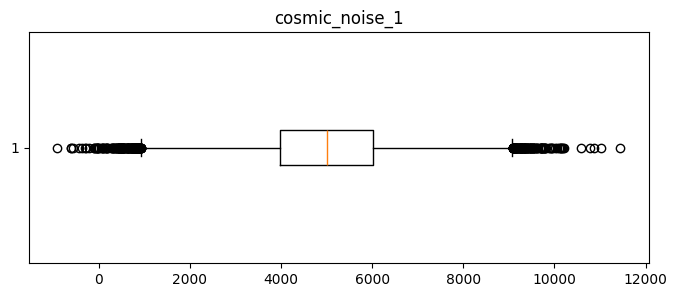

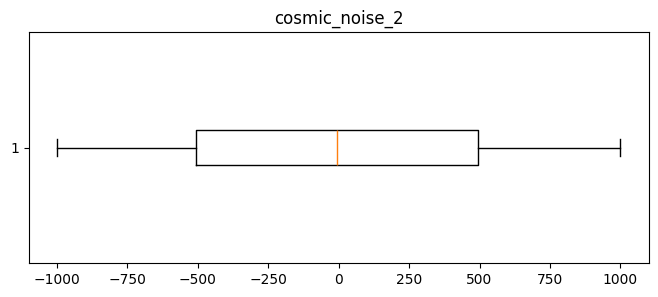

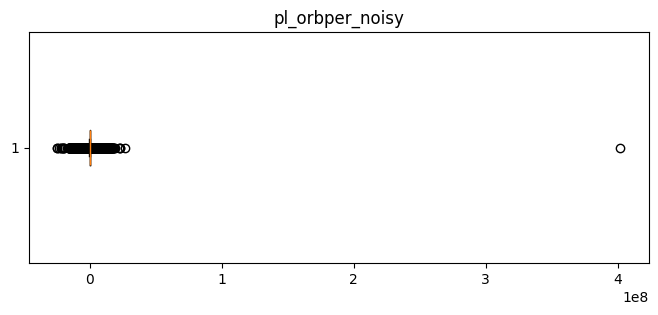

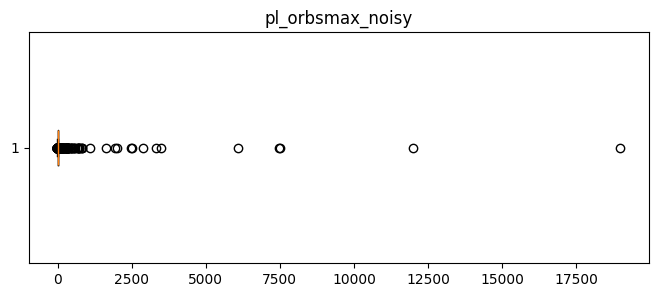

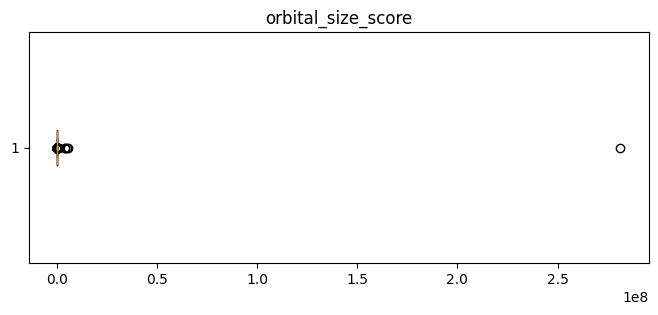

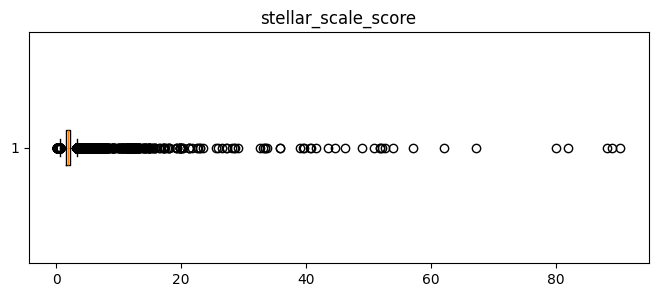

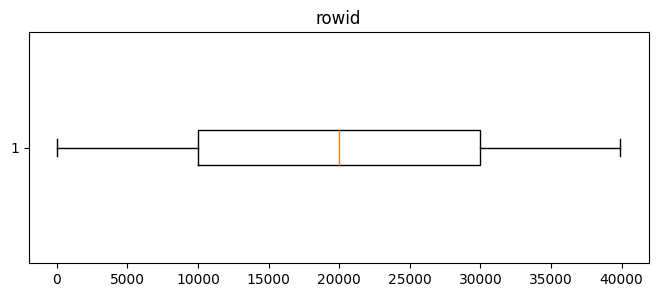

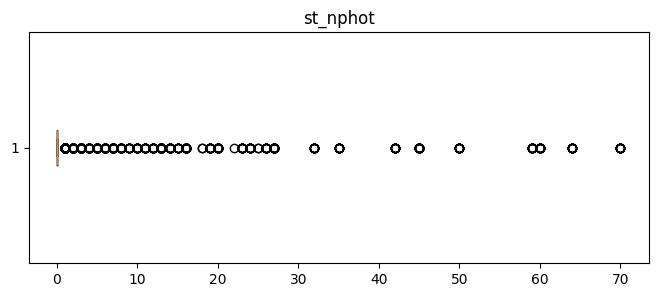

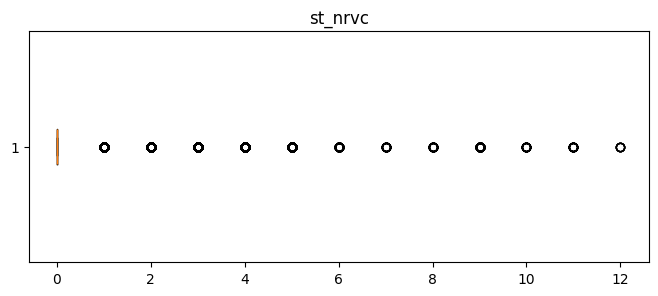

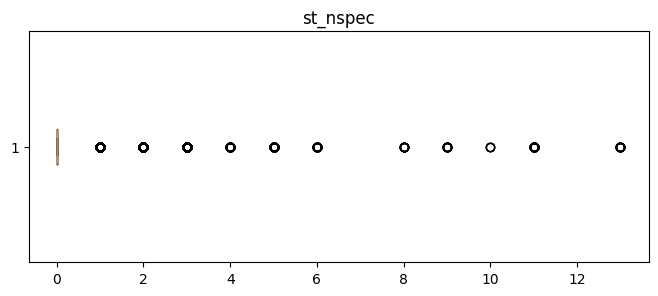

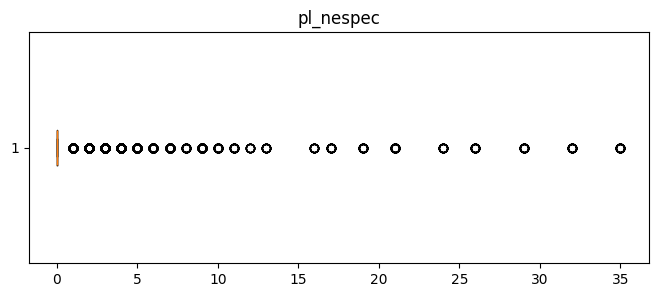

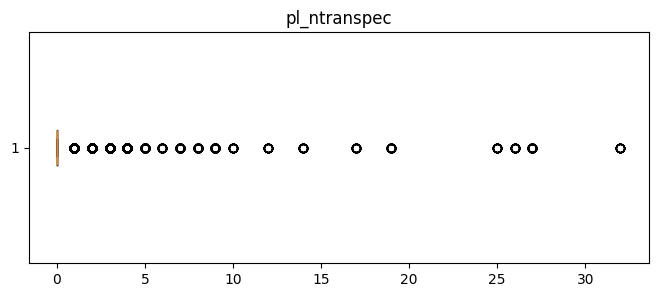

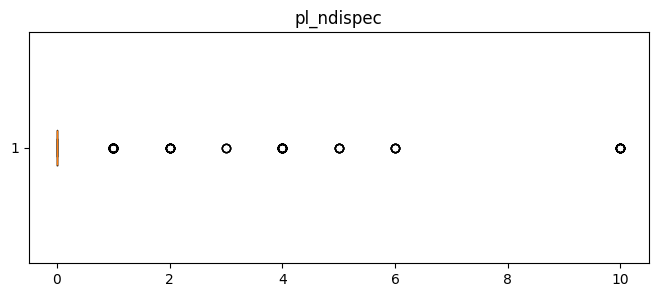

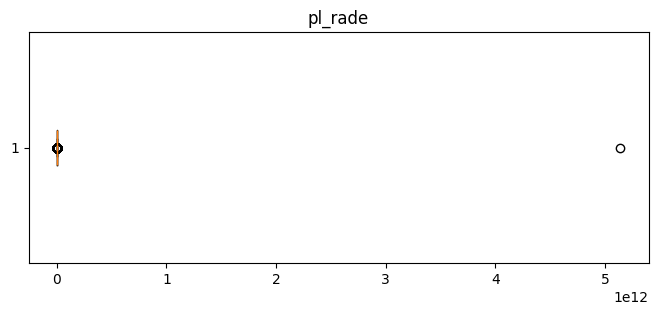

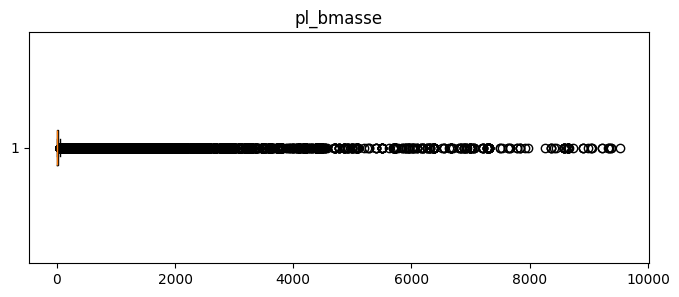

In [5]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

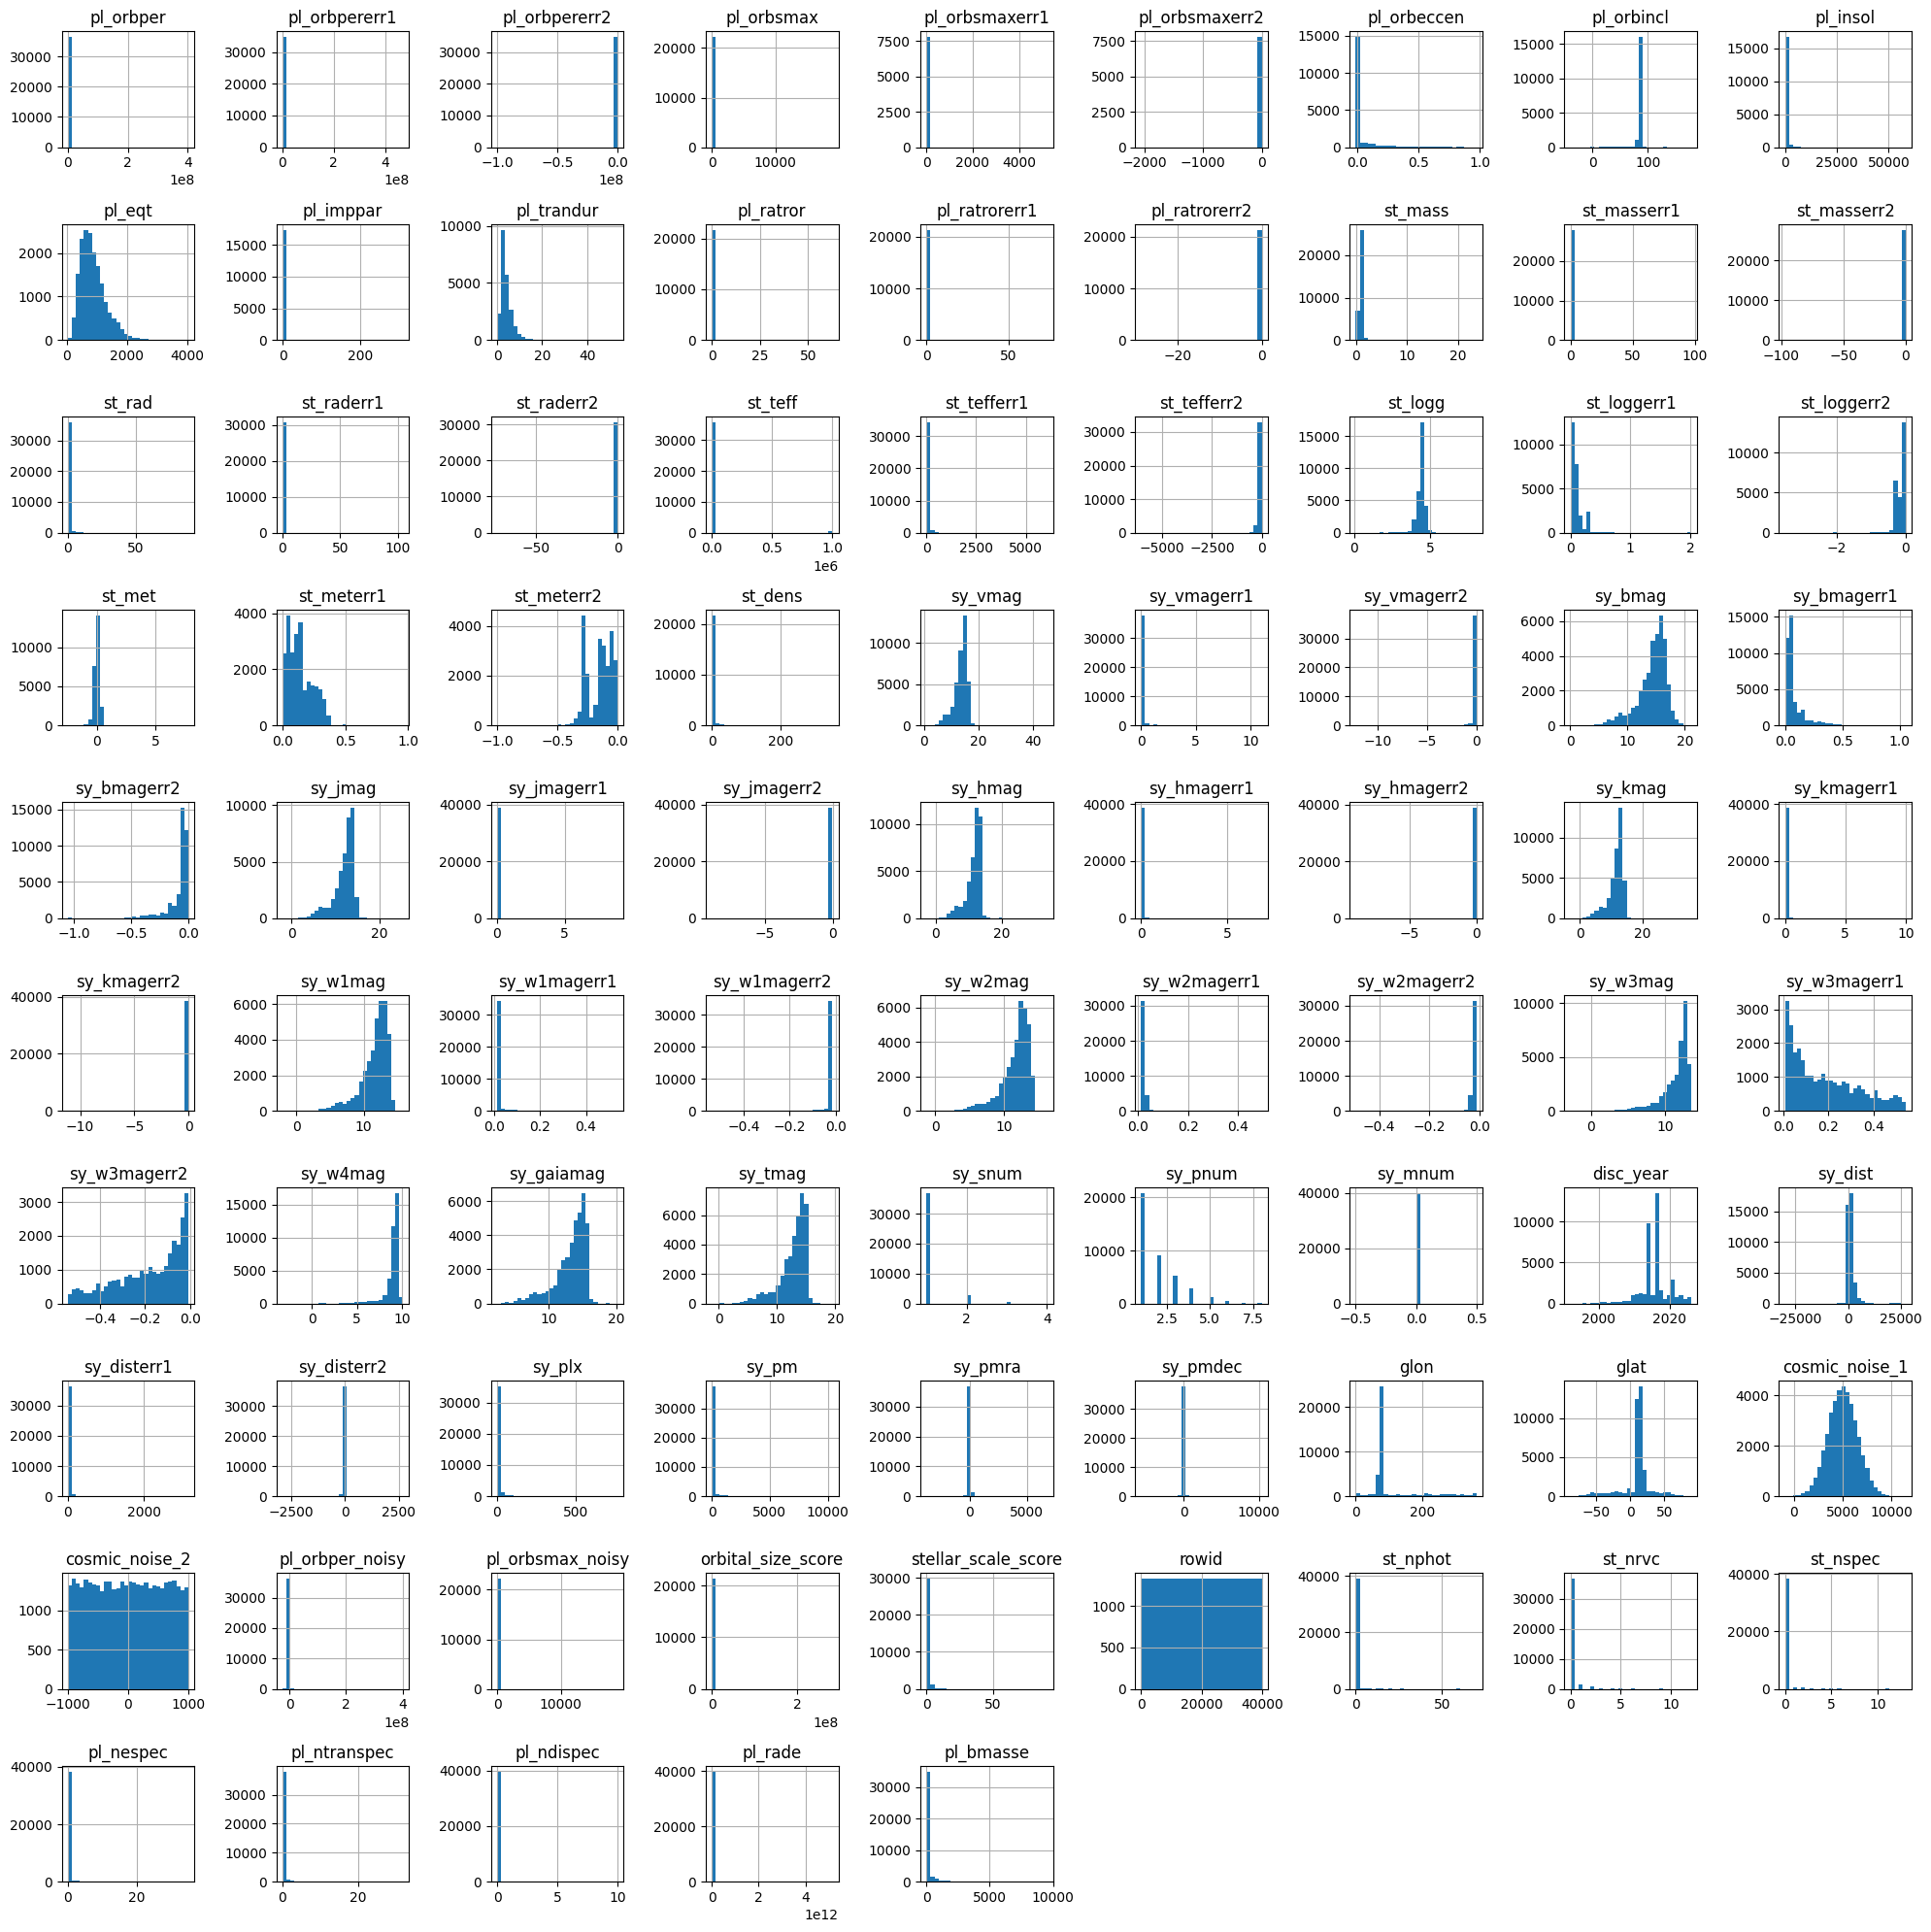

In [22]:
import matplotlib.pyplot as plt

df.hist(figsize=(20,20), bins=30)

plt.tight_layout()

plt.show()

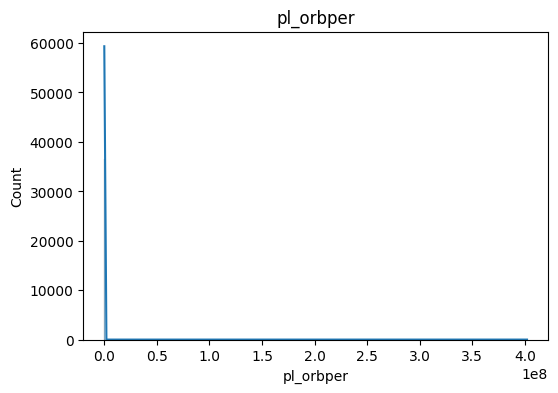

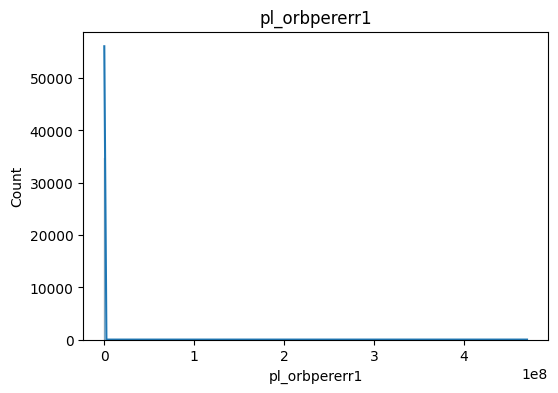

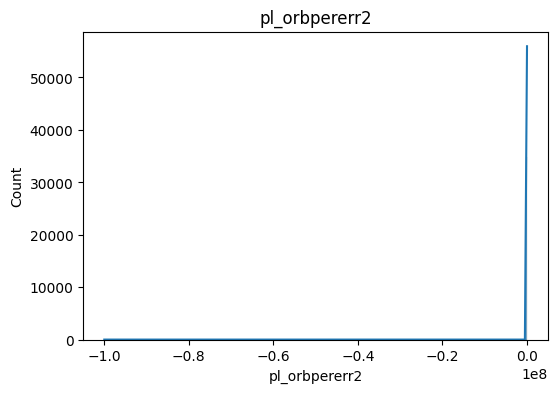

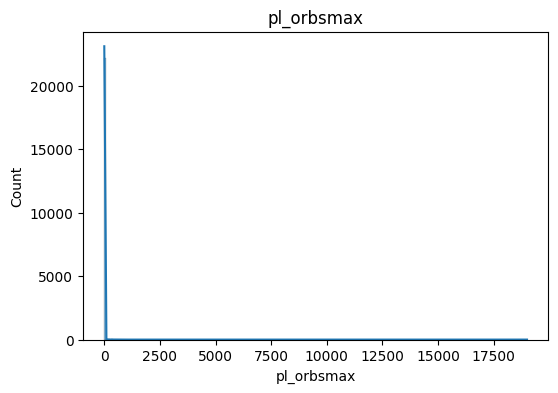

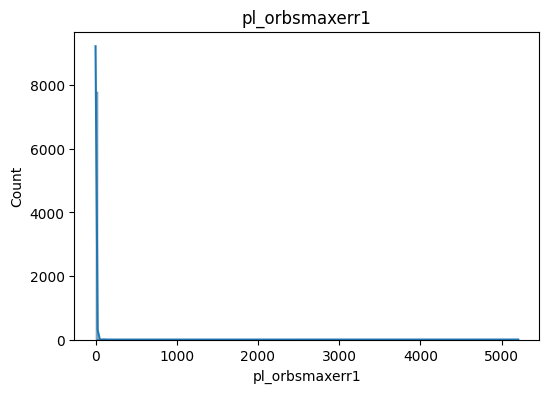

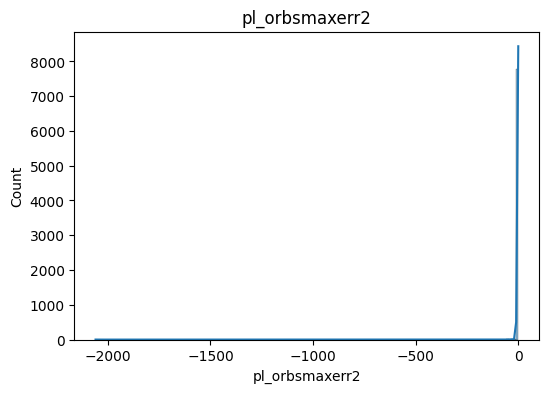

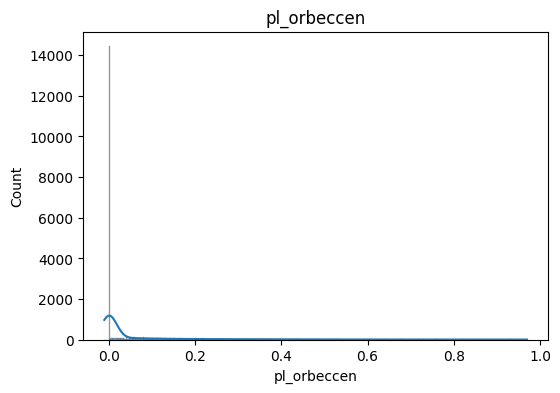

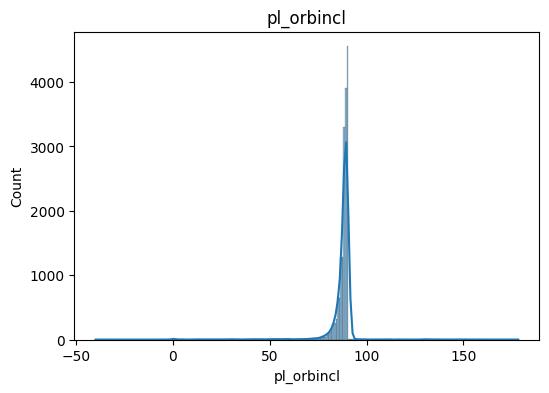

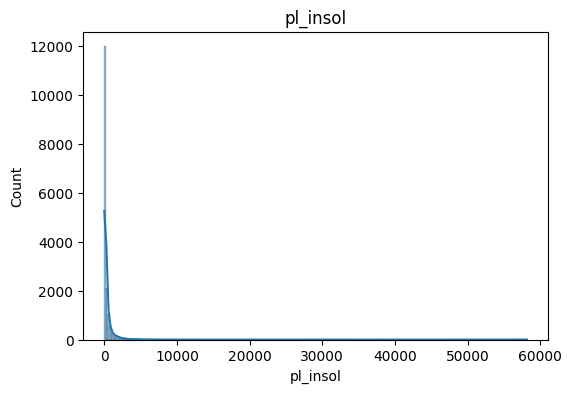

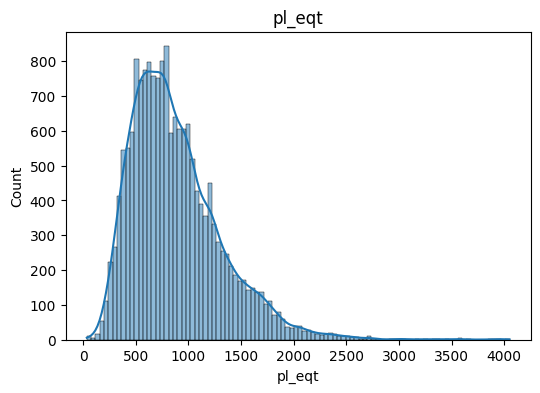

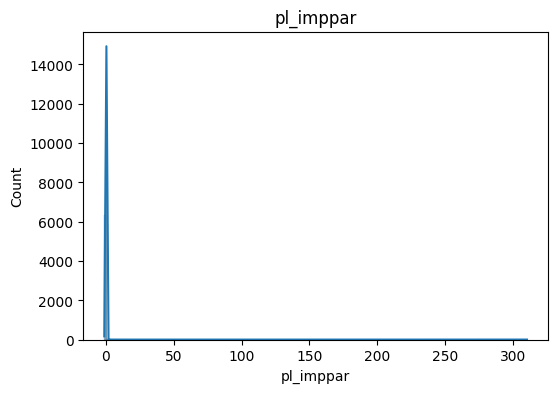

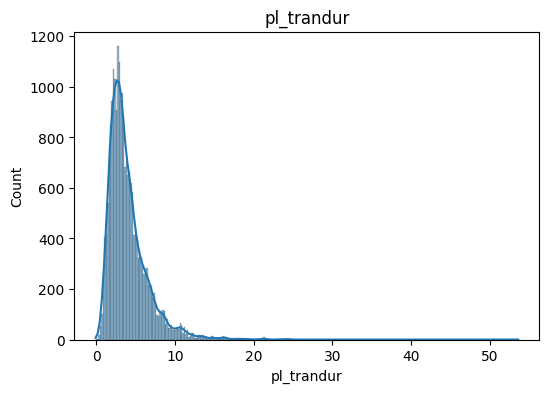

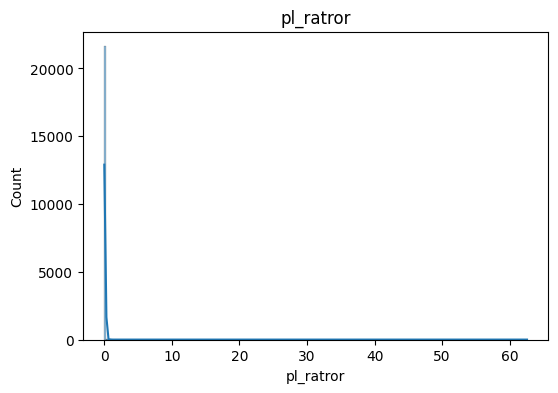

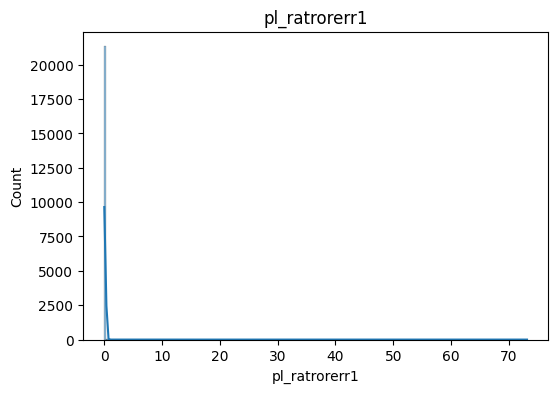

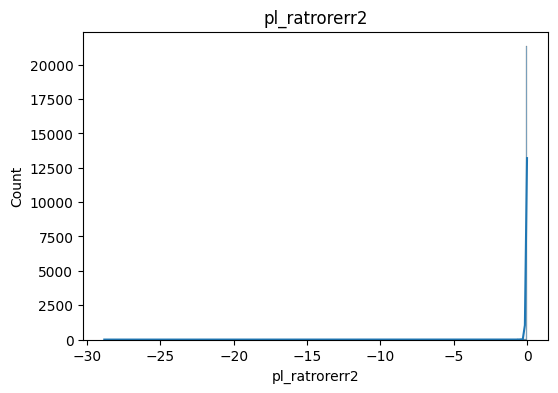

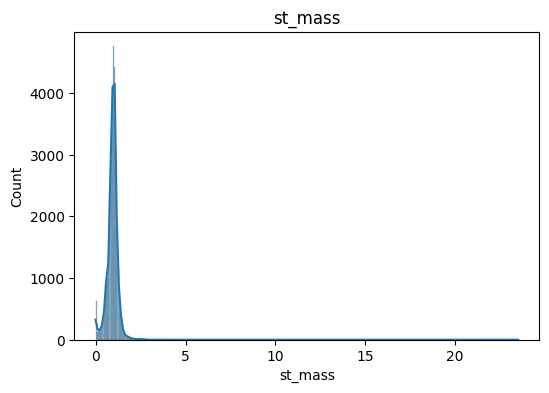

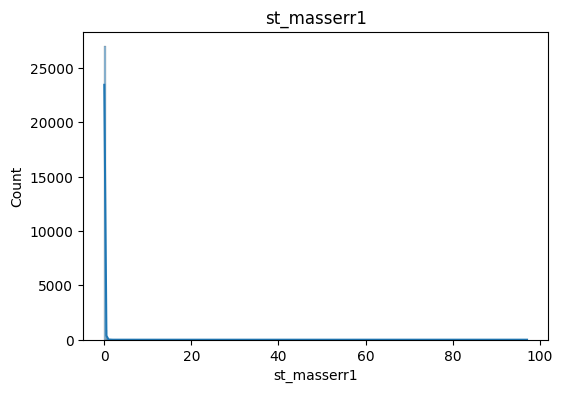

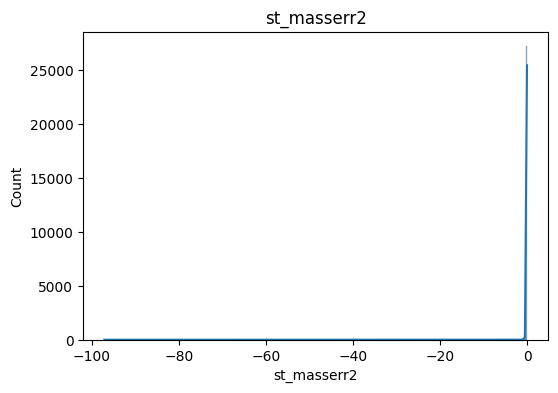

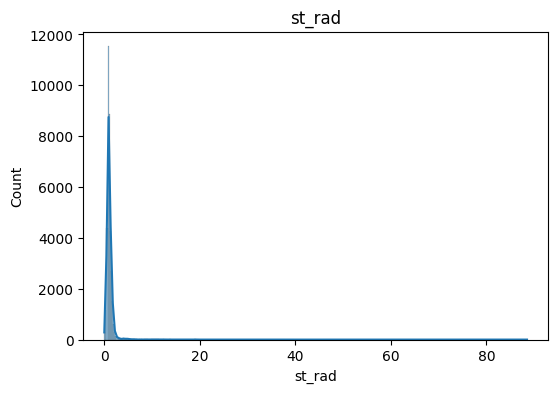

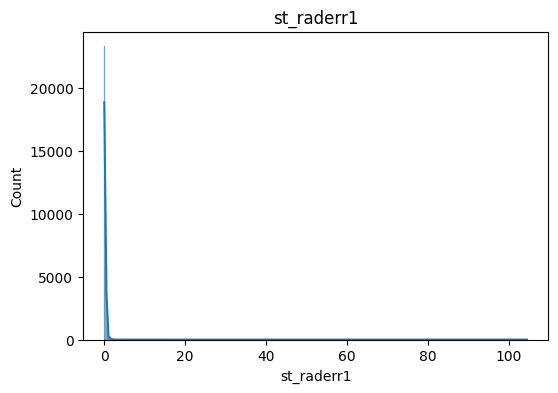

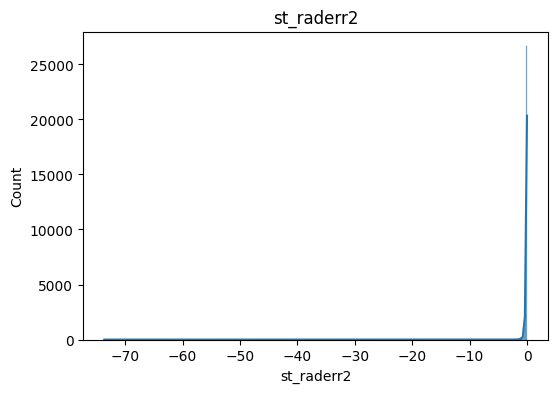

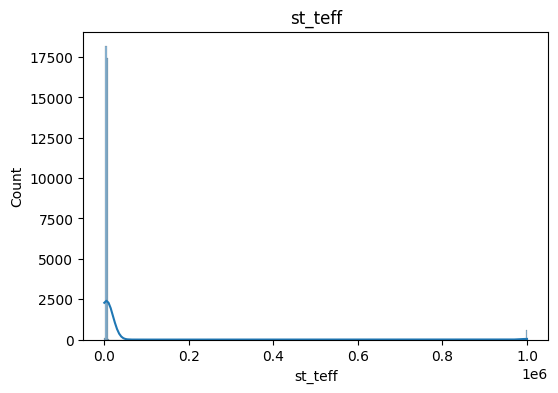

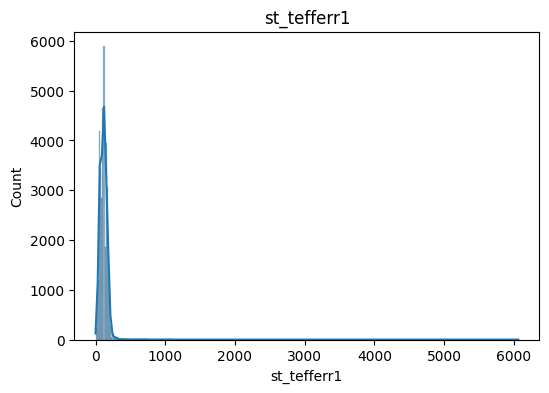

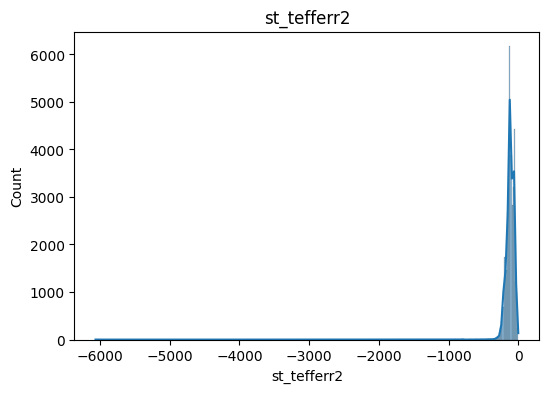

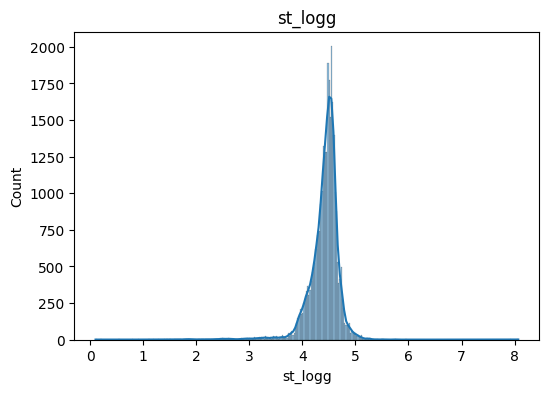

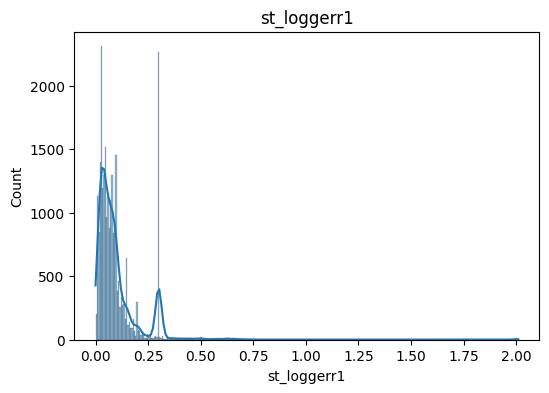

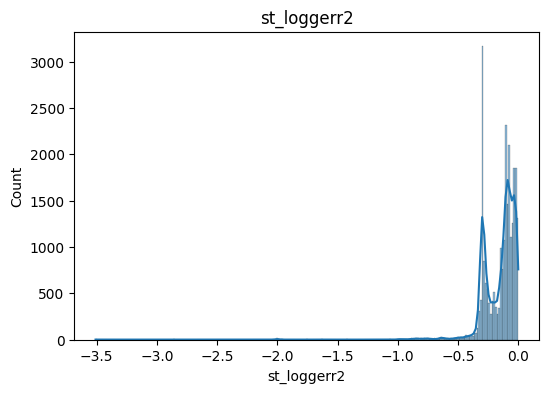

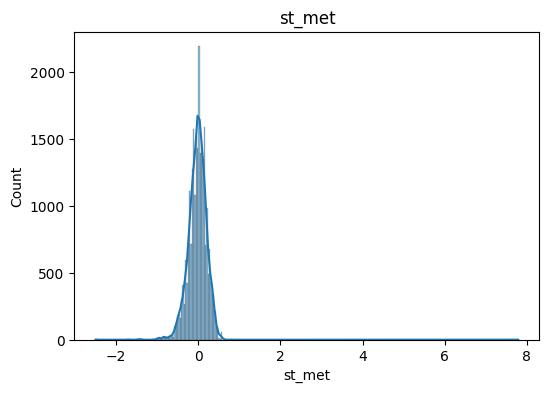

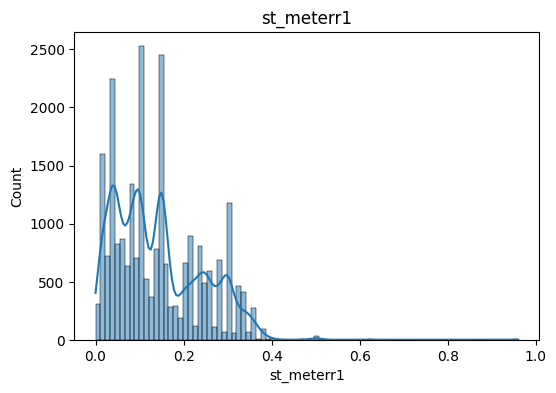

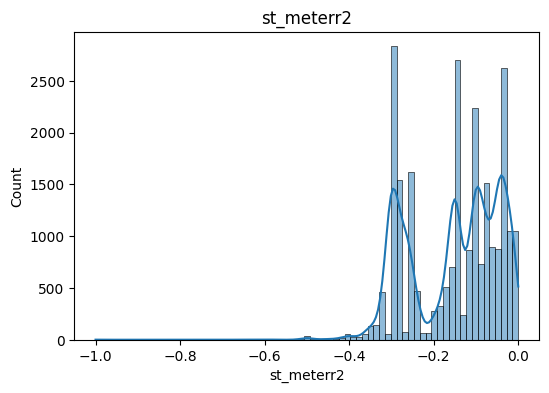

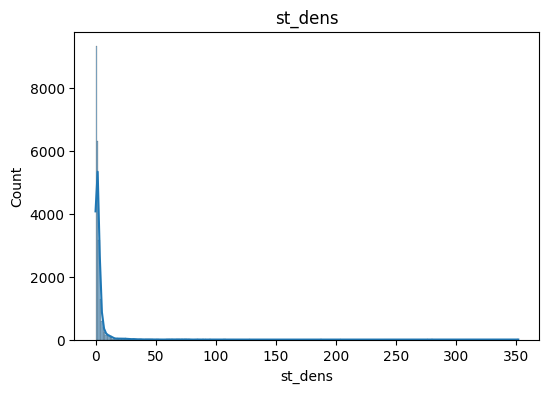

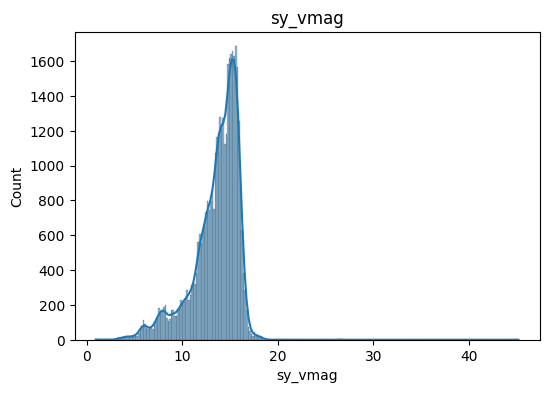

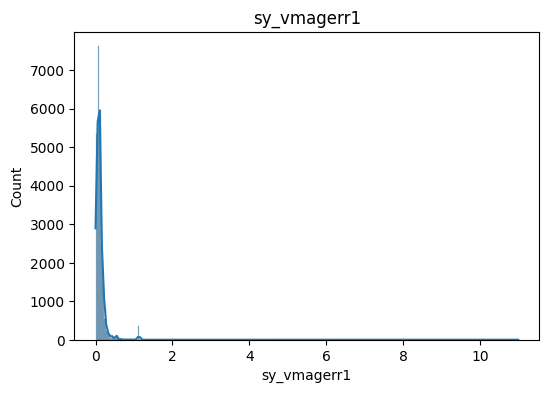

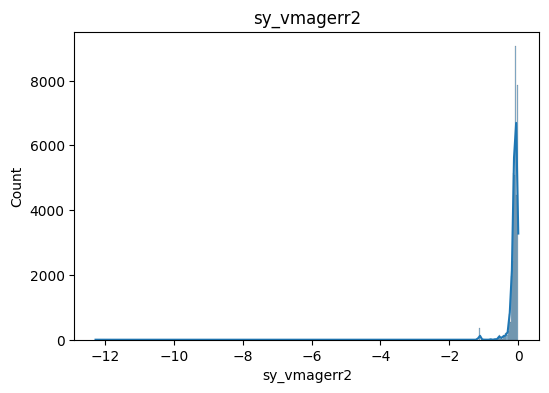

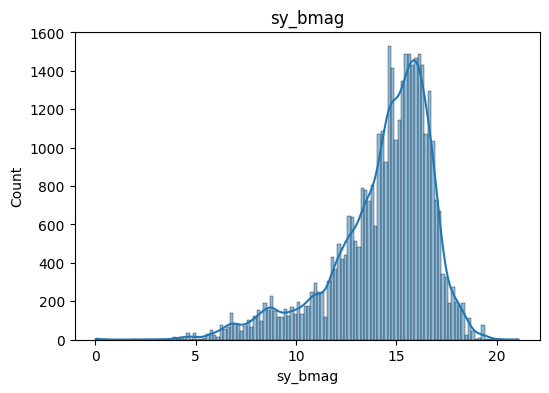

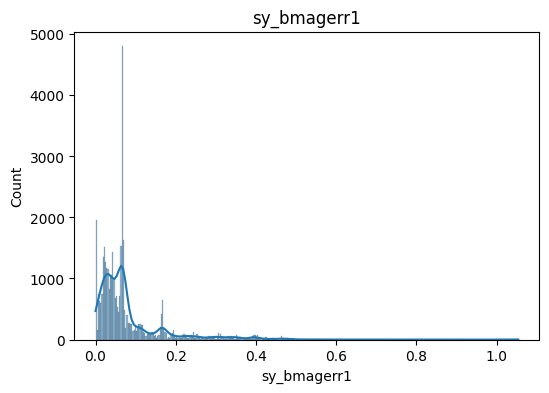

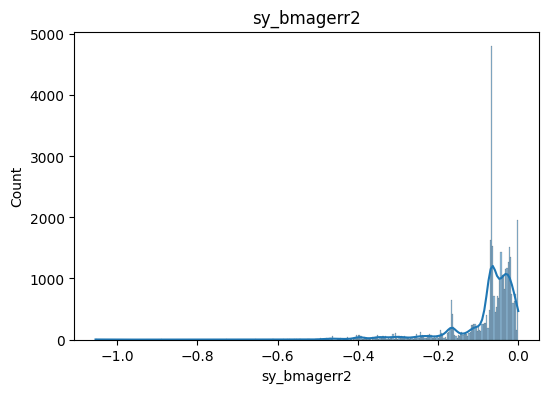

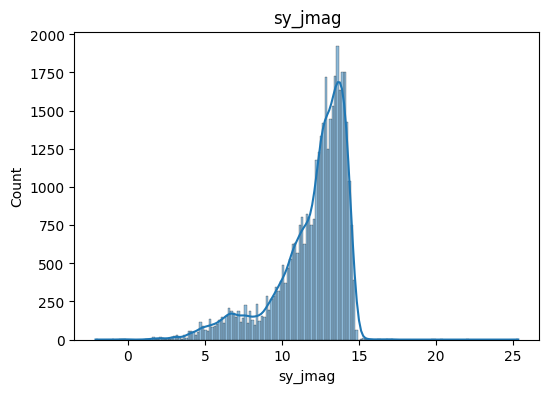

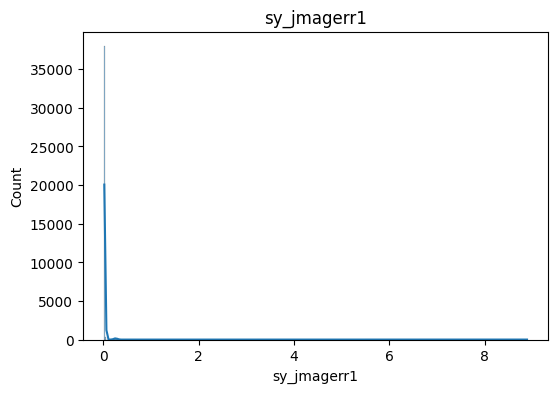

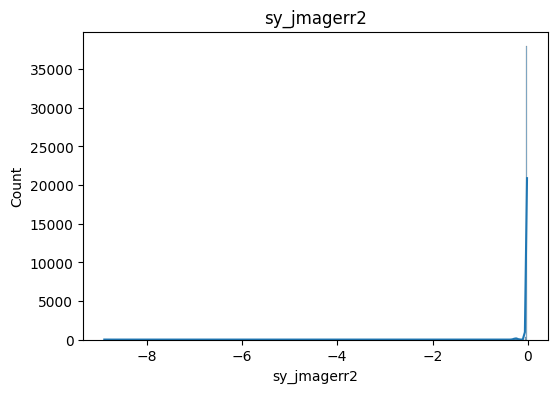

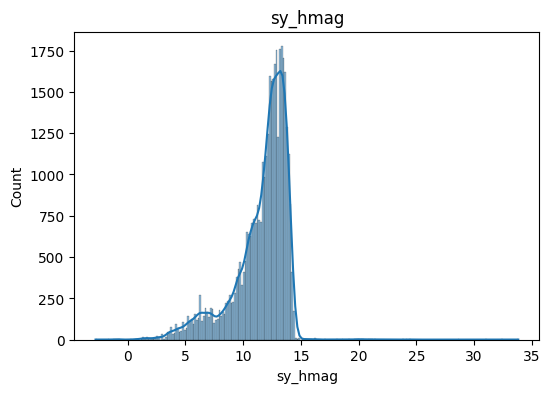

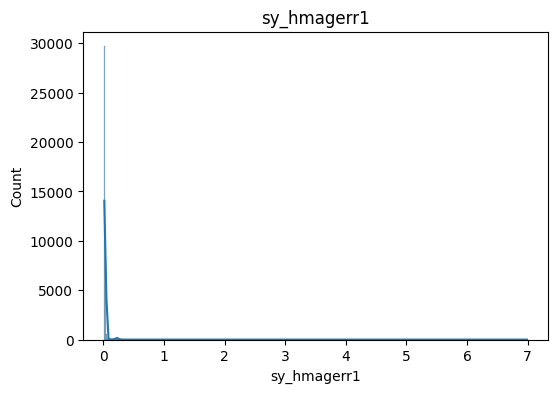

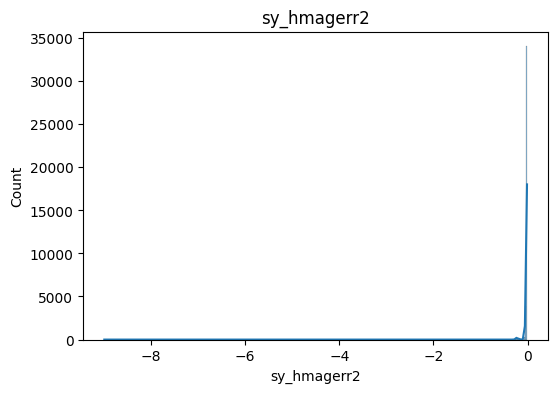

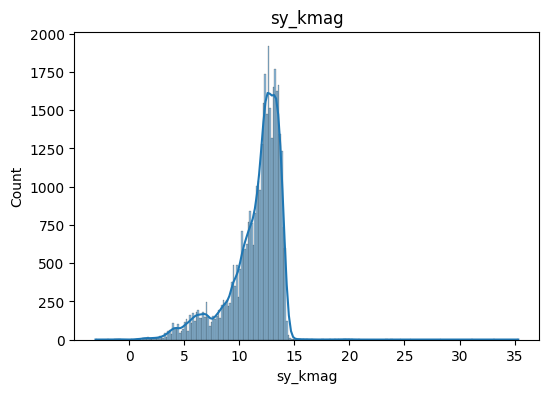

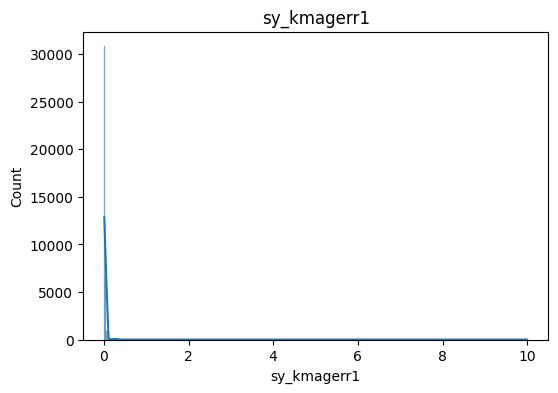

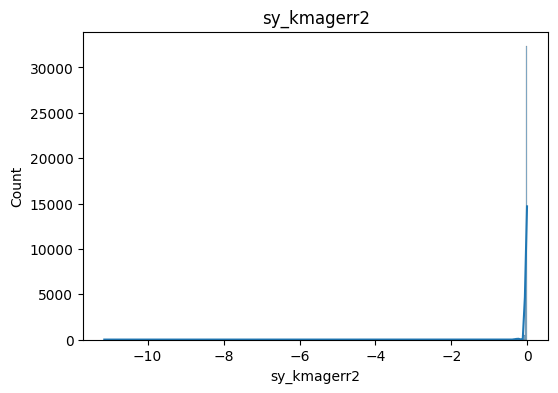

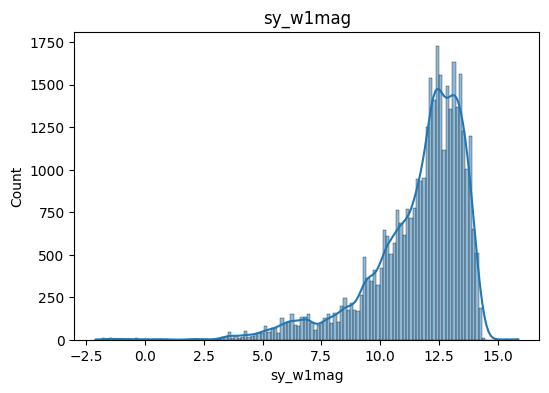

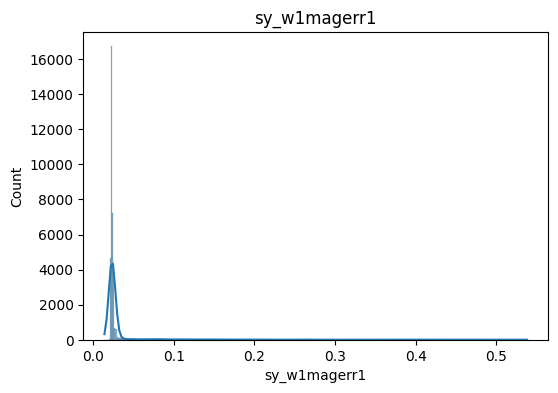

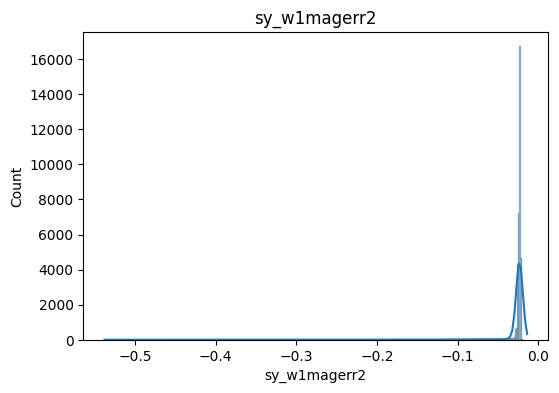

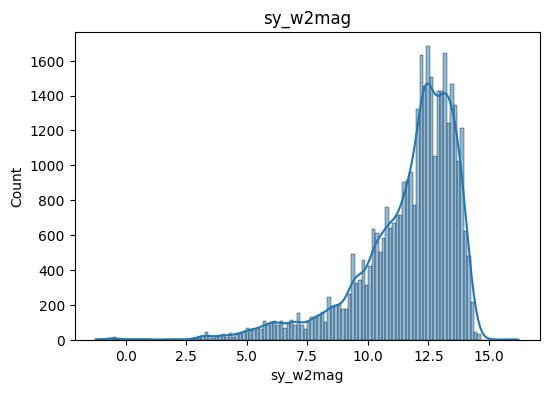

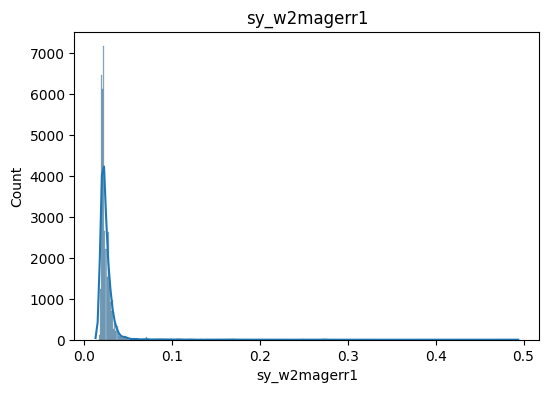

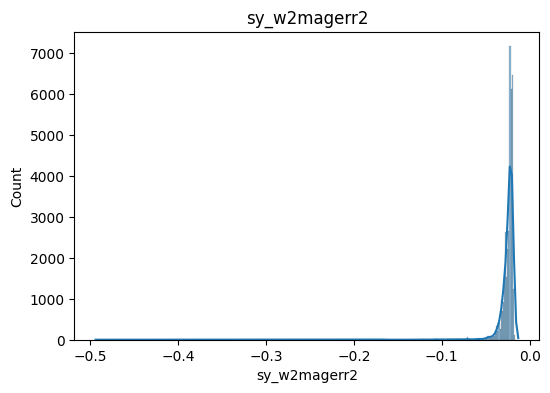

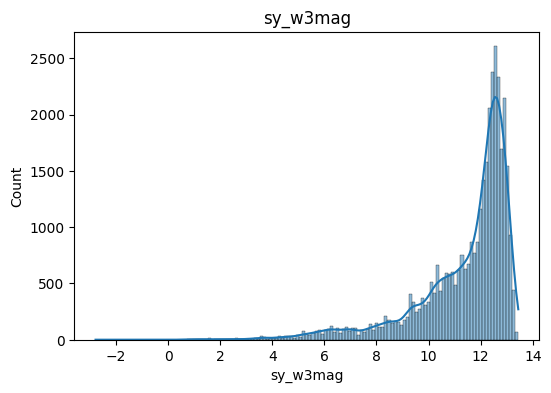

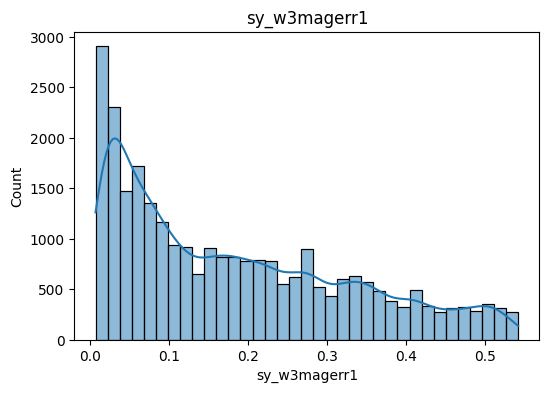

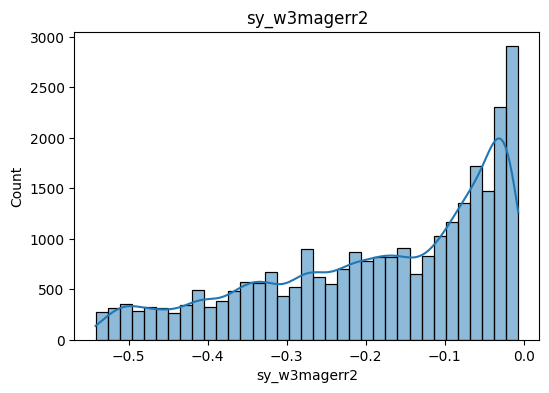

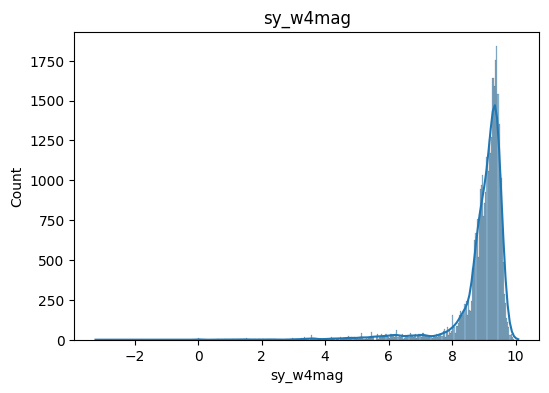

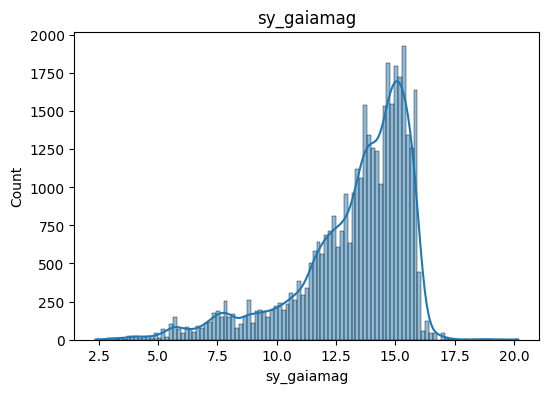

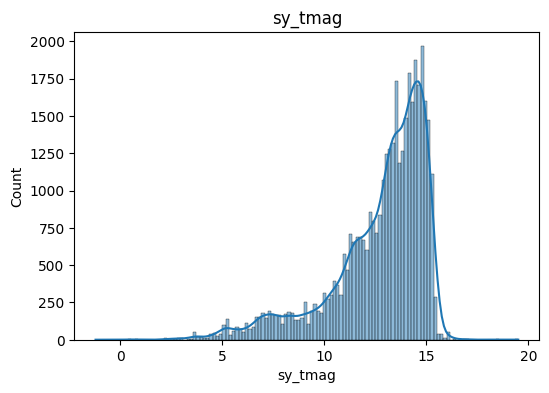

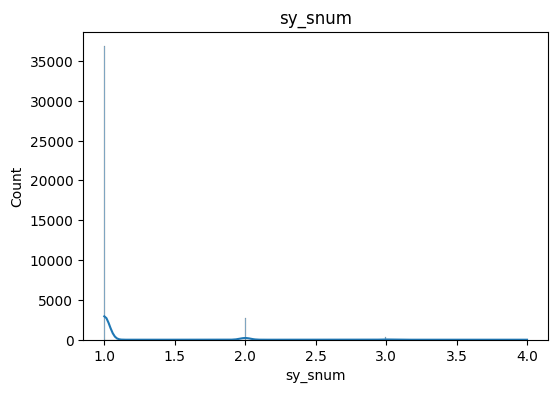

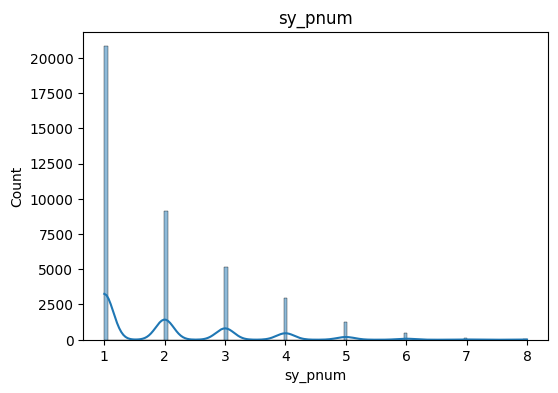

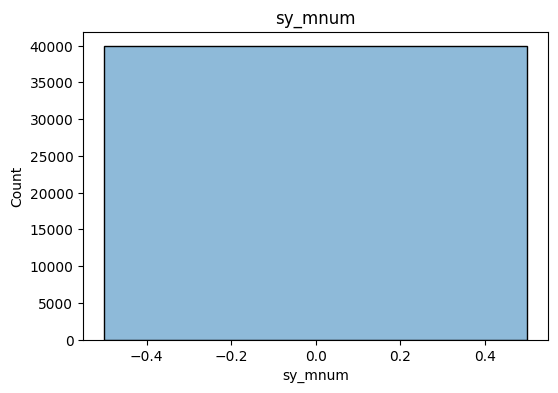

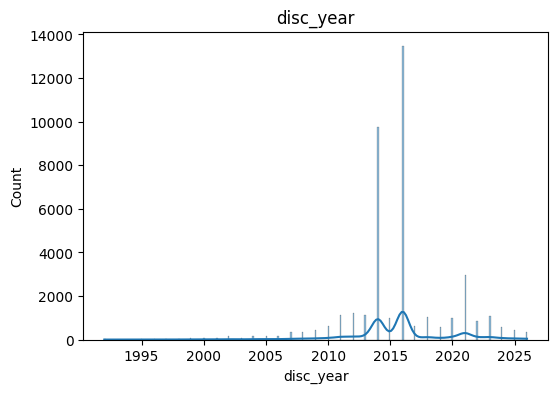

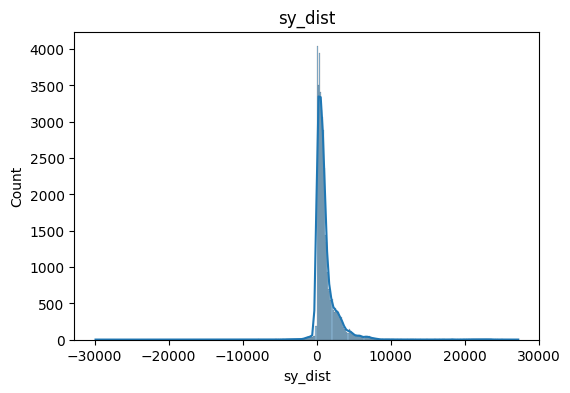

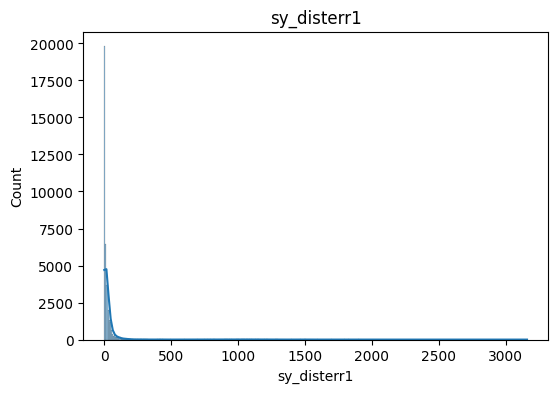

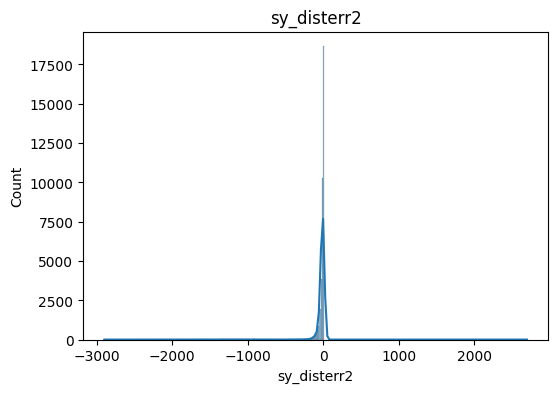

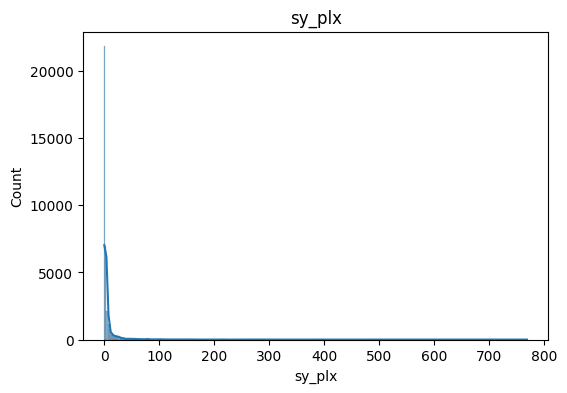

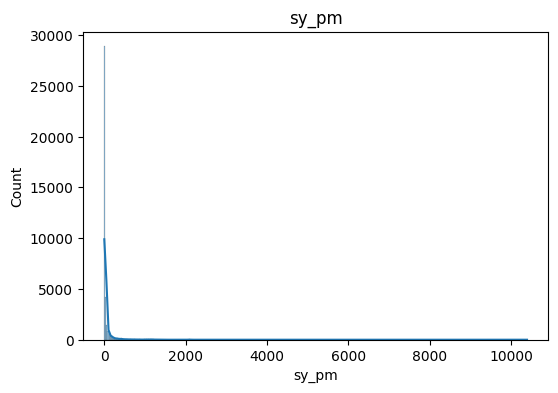

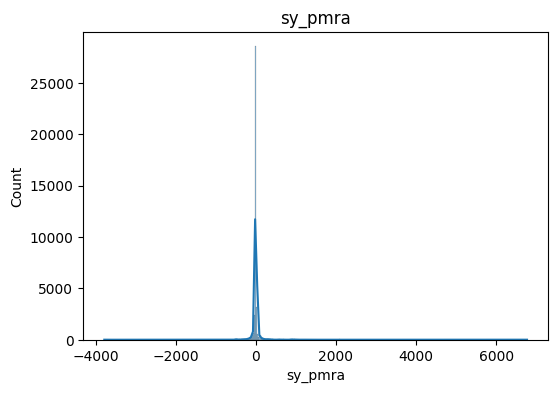

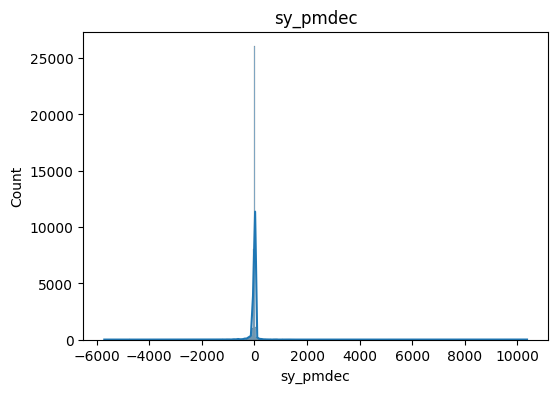

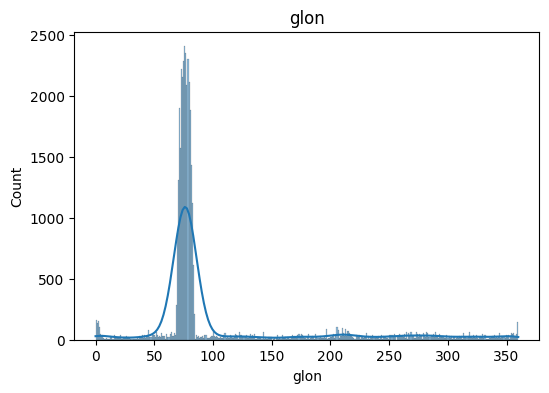

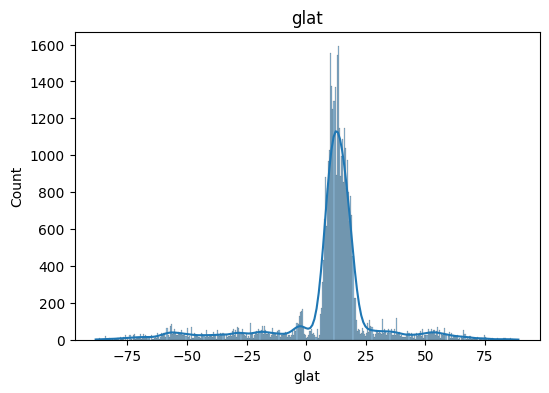

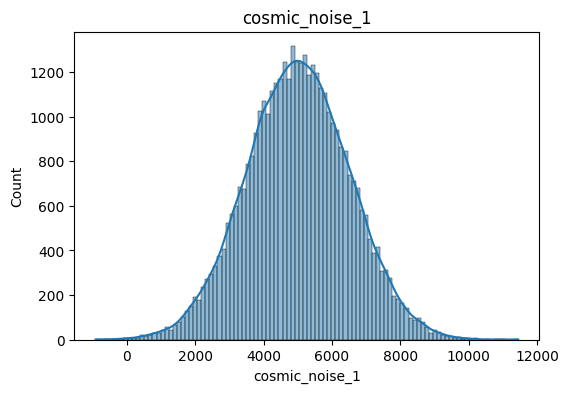

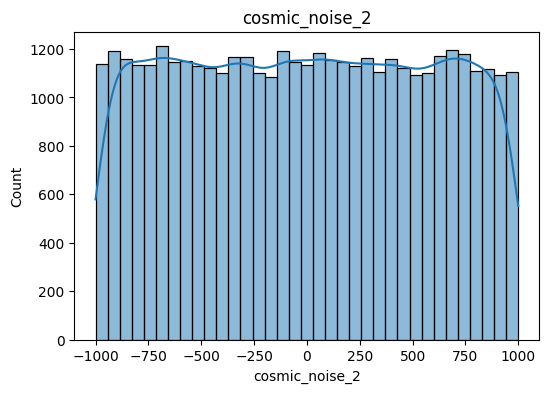

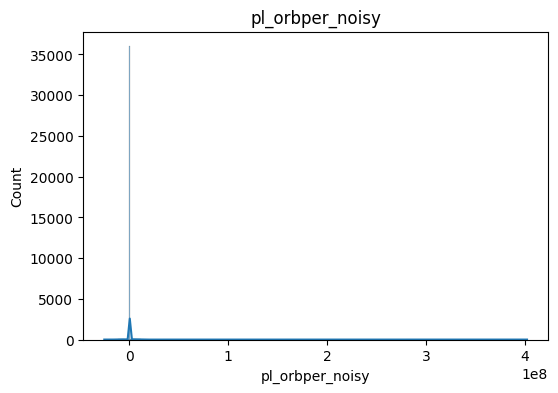

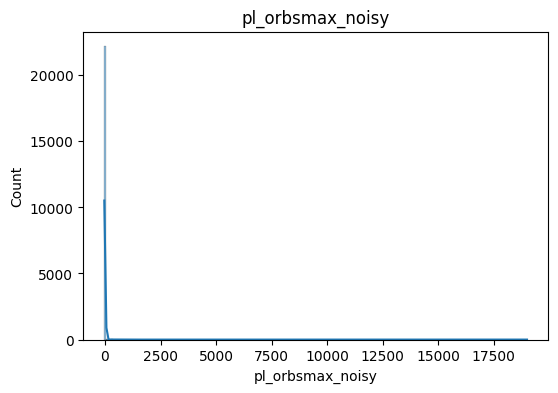

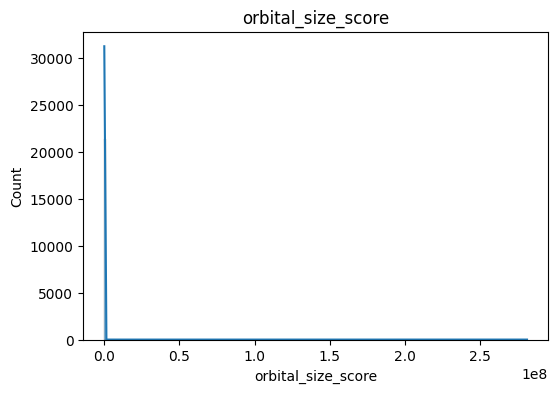

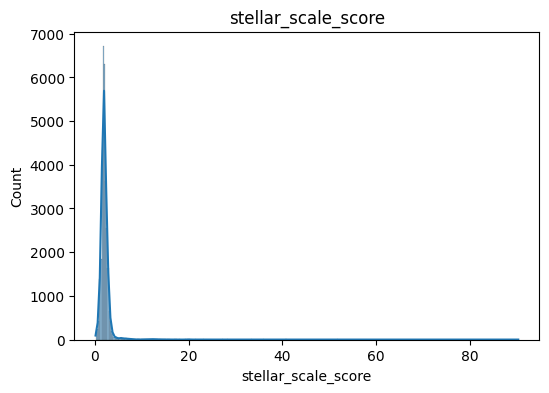

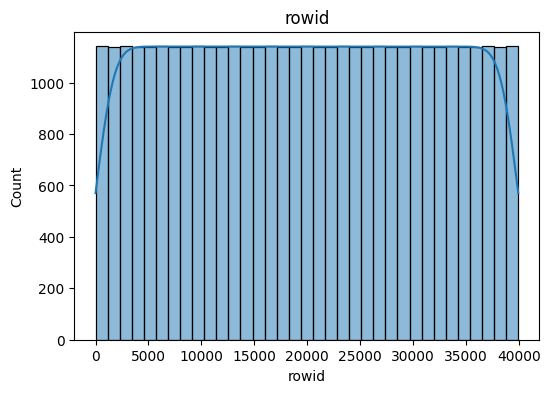

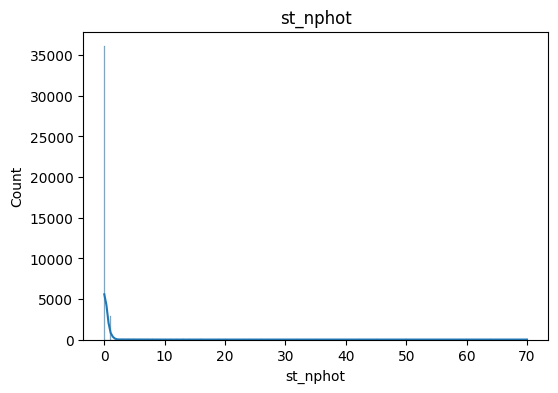

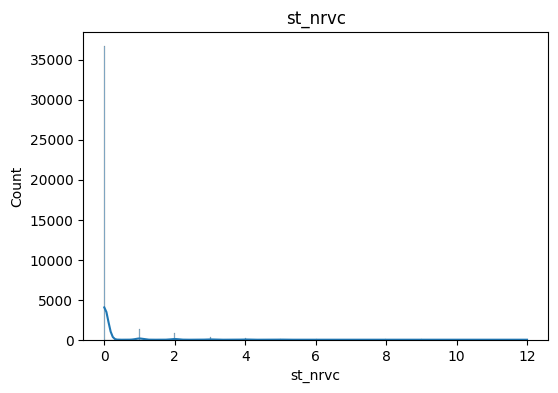

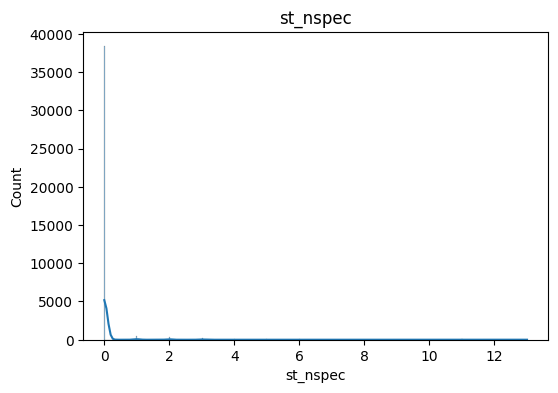

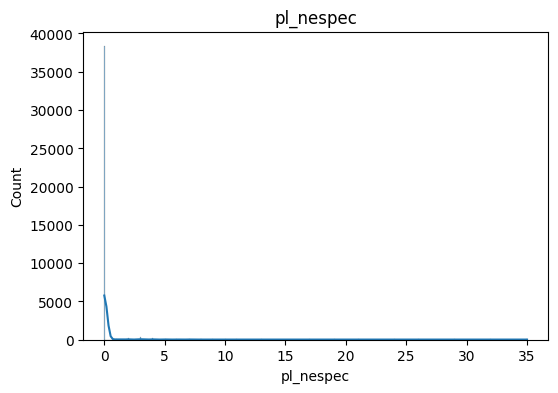

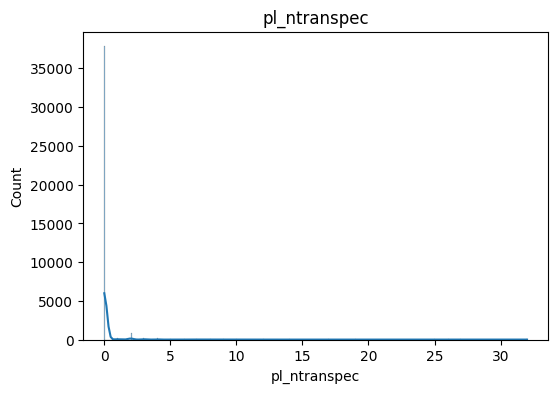

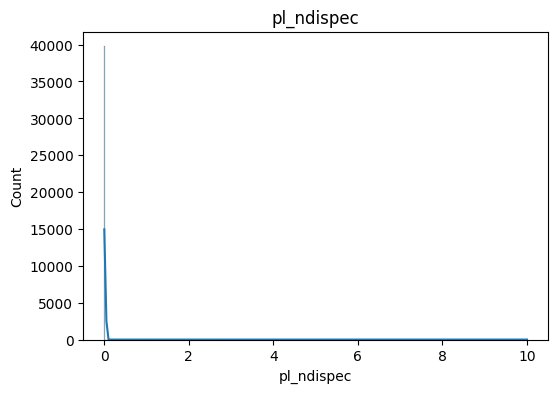

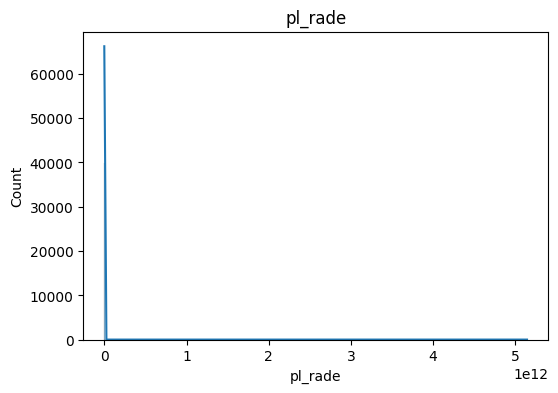

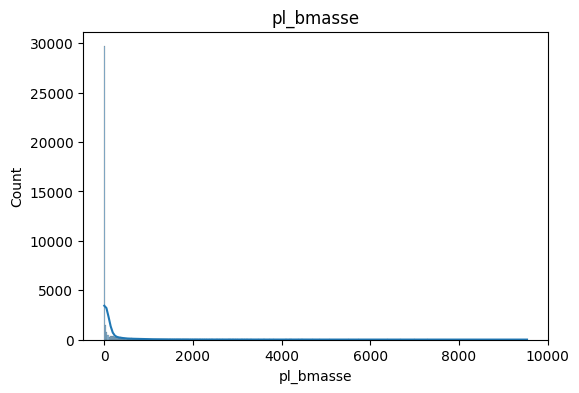

In [23]:
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [24]:
df_clean = df.copy()
km_mask = (df_clean['pl_rade'] > 500) & (df_clean['pl_rade'] < 100000)
df_clean.loc[km_mask, 'pl_rade'] = df_clean.loc[km_mask, 'pl_rade'] / 6371.0

In [25]:
df_clean = df_clean[(df_clean['pl_rade'] > 0.1) & (df_clean['pl_rade'] <= 50)].copy()

In [26]:
df_clean['pl_rade_phys'] = df_clean['st_rad'] * df_clean['pl_ratror'] * 109.0763


In [27]:
drop_cols = [
    'pl_rade', 'rowid', 'pl_name', 'hostname', 'pl_letter', 
    'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate',
    'cosmic_noise_1', 'cosmic_noise_2', 'pl_orbper_noisy', 'pl_orbsmax_noisy',
    'discoverymethod', 'disc_facility', 'soltype'
]

#### Machine learning Model

In [28]:
X = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
y = df_clean['pl_rade']

In [29]:
y_log = np.log1p(y)

In [30]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test = np.expm1(y_test_log)


In [31]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

In [32]:
model.fit(X_train, y_train_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16643
[LightGBM] [Info] Number of data points in the train set: 31904, number of used features: 80
[LightGBM] [Info] Start training from score 1.280599


,learning_rate,0.03
,n_estimators,500
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [33]:
y_pred_log = model.predict(X_test)

### Model Evaluation

In [35]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [36]:

print("--- Model Performance Metrics ---")
print(f"MAE:  {mae:.4f} Earth Radii")
print(f"RMSE: {rmse:.4f} Earth Radii")
print(f"R² Score: {r2:.4f}")

--- Model Performance Metrics ---
MAE:  0.4033 Earth Radii
RMSE: 1.2838 Earth Radii
R² Score: 0.8516
